## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "mass_smaller_3"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [4]:
override = False
use_preds = True
save = True
show = True

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


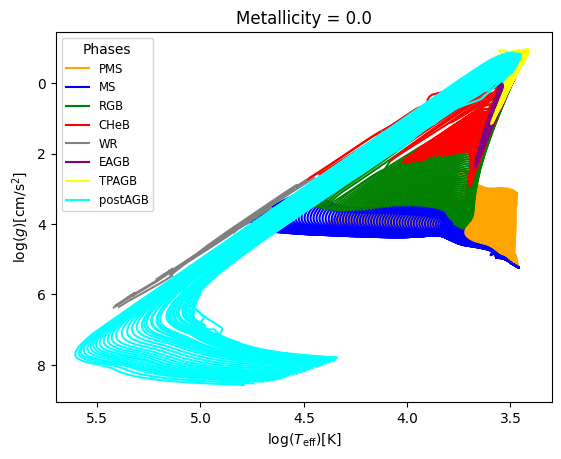

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

In [6]:
print_uniques("star_mass", iso_df)
# print_uniques_count("star_mass", iso_df)

star_mass : 1467117 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


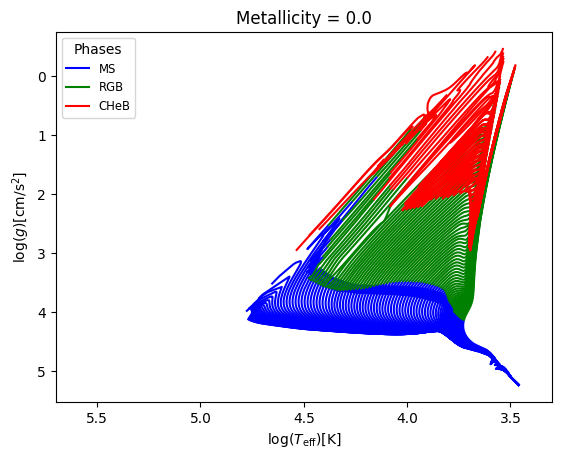

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_uniques("star_mass", phase_filtered_iso_df)
# print_uniques_count("star_mass", phase_filtered_iso_df)

star_mass : 630605 unique values, range [0.0999979840073621, 298.5447575808816]


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,6.50,4.126429,4.449033,0.0,-0.25,2.859137,0.222566
1,6.50,4.130406,4.448602,0.0,-0.25,2.900395,0.225872
2,6.50,4.134480,4.448201,0.0,-0.25,2.941695,0.229166
3,6.50,4.138527,4.447853,0.0,-0.25,2.982876,0.232424
4,6.55,4.113582,4.450139,0.0,-0.25,2.734122,0.212411
...,...,...,...,...,...,...,...
320423,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
320424,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
320425,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
320426,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


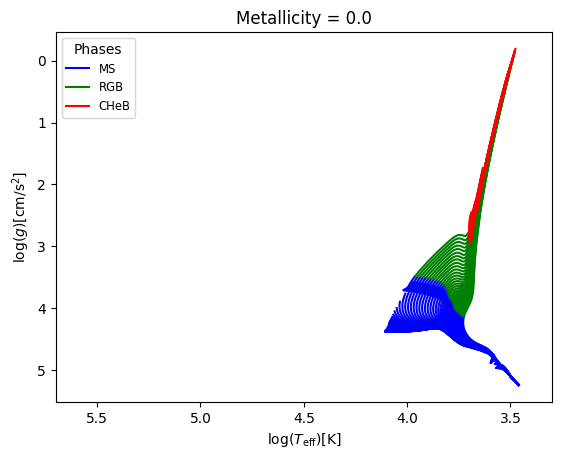

In [9]:
phase_mass_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], "star_mass" : ("<", 3)})
display(phase_mass_filtered_iso_df)
data_visualiser_phase_age_filtered = Data_visualiser(phase_mass_filtered_iso_df, physical_model)
data_visualiser_phase_age_filtered.plot_Kiel([], [0.0])

In [10]:
print_all_uniques(phase_mass_filtered_iso_df)

log10_isochrone_age_yr  : Range : 6.2 - 10.3, Mean : 9.0993, Median : 9.2

log_Teff  : Range : 3.34 - 4.3013, Mean : 3.795, Median : 3.7533

log_g  : Range : -1.08 - 5.4331, Mean : 3.6429, Median : 4.1661

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 3.0, Mean : 1.3237, Median : 1.1896

log_R  : Range : -1.0 - 2.7813, Mean : 0.4164, Median : 0.2391



In [11]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_mass_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 2.9999868374941867
Median value in train data for the star_mass parameter: 1.1896713804332213
Mean value in train data for the star_mass parameter: 1.323717089614089

Range in train data for the log_R parameter : -0.9974747647513328 - 2.7813065611193197
Median value in train data for the log_R parameter: 0.2392300004319432
Mean value in train data for the log_R parameter: 0.4157857297090251

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999982496805748 - 2.9998113988348285
Median value in test data for the star_mass parameter: 1.188655743968008
Mean value in test data for the star_mass parameter: 1.3236260288359496

Range in test data for the log_R parameter : -0.9963305599370684 - 2.772287451333455
Median value in test data for the log_R parameter: 0.2386171072364609
Mean value in test data for the log_R parameter: 0.41815215510455067

(240321, 4) (80107, 4)
(2

## Model training

### Linear regression

In [12]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.8838520137942808
  RMSE :  0.26302269018329616
  MAE :  0.20893526575970198
  MedAE :  0.17473275347953293
  CORR :  0.9456040197306378
  MAX_ER :  0.8849536923842489
  Percentiles : 
    75th percentile :  0.29173086622884714
    90th percentile :  0.44228361209899864
    95th percentile :  0.5334178089086604
    99th percentile :  0.679584733913645

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.6152163506955306
  RMSE :  0.40368841616545115
  MAE :  0.3068834649282035
  MedAE :  0.23297282355440885
  CORR :  0.8455102812660852
  MAX_ER :  1.3330982300568945
  Percentiles : 
    75th percentile :  0.44357472400021936
    90th percentile :  0.6734707227156216
    95th percentile :  0.8540137210591918
    99th percentile :  1.14038193

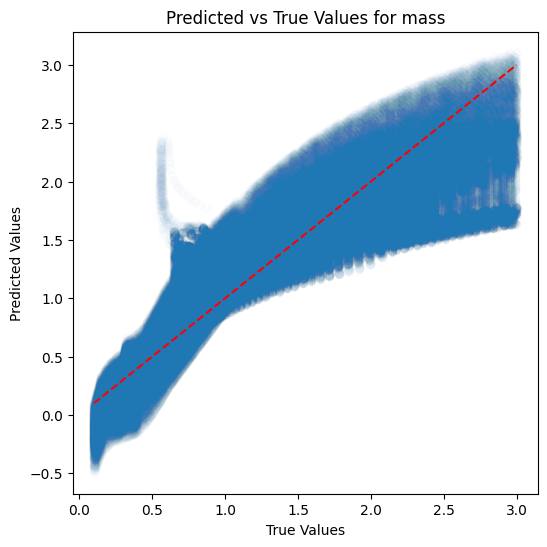

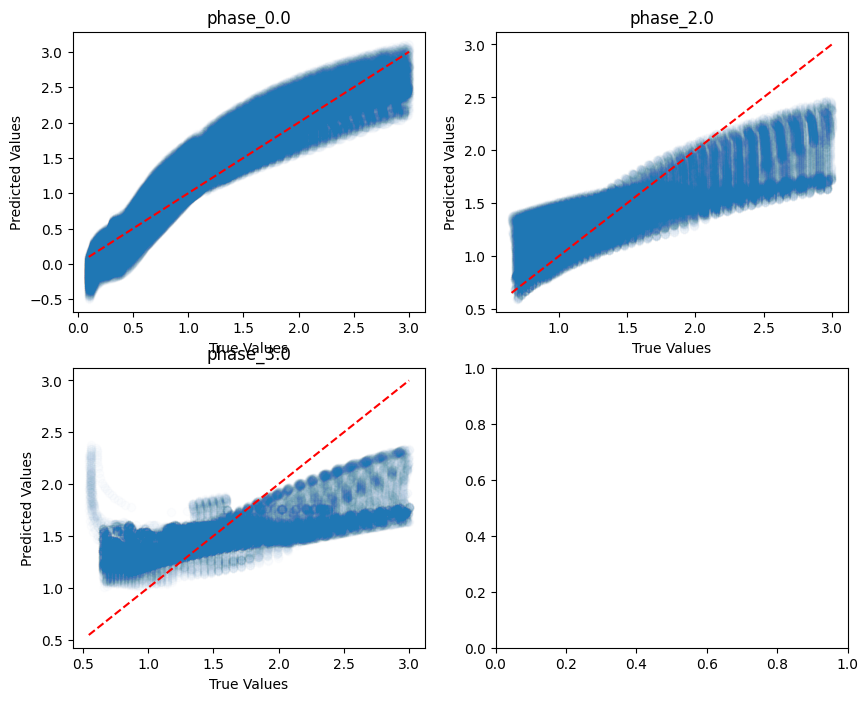

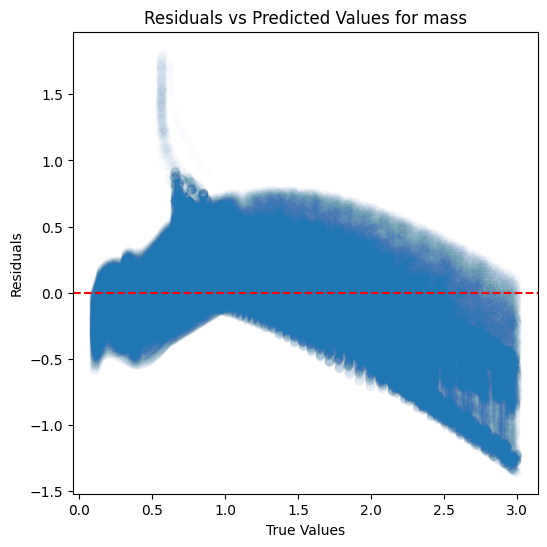

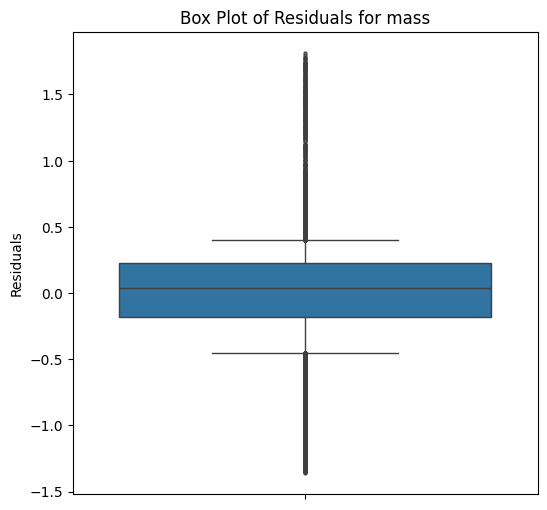

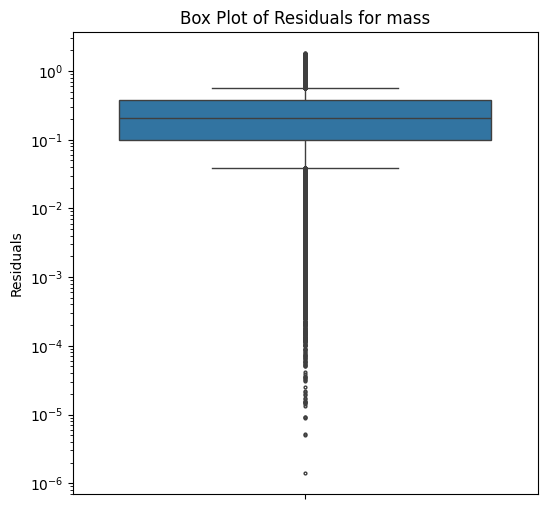

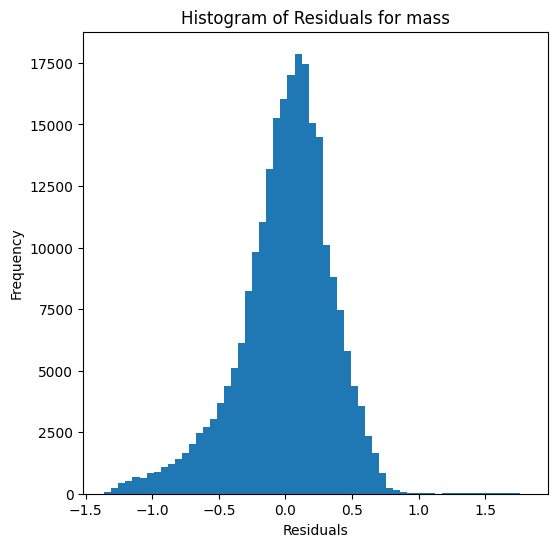

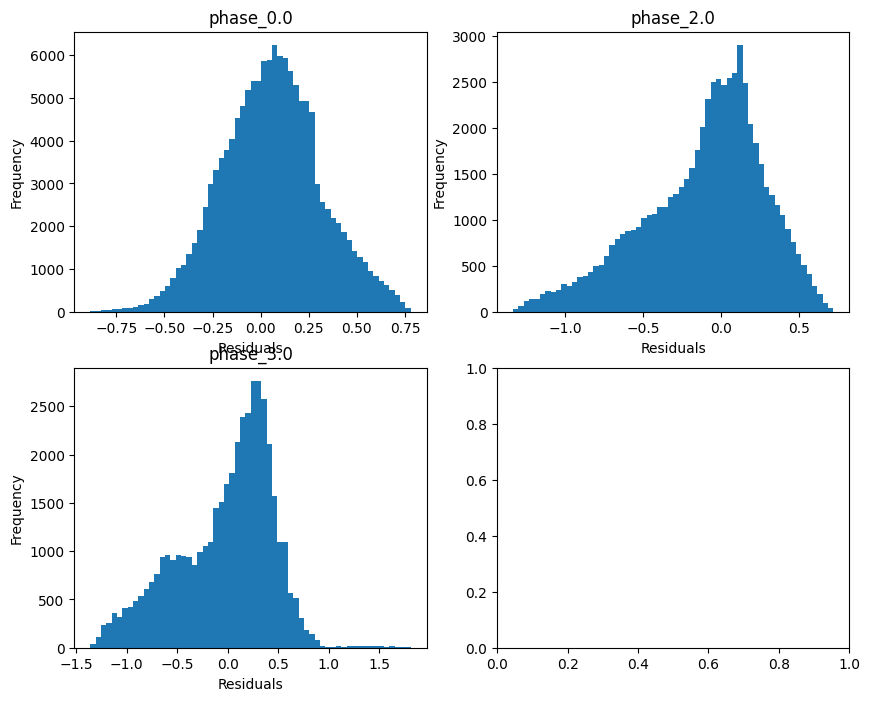

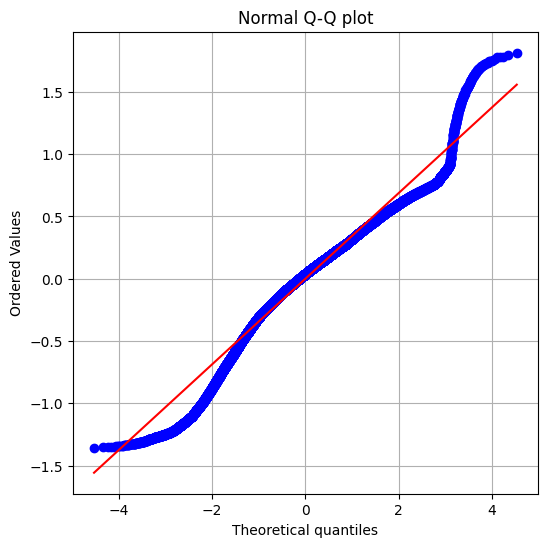

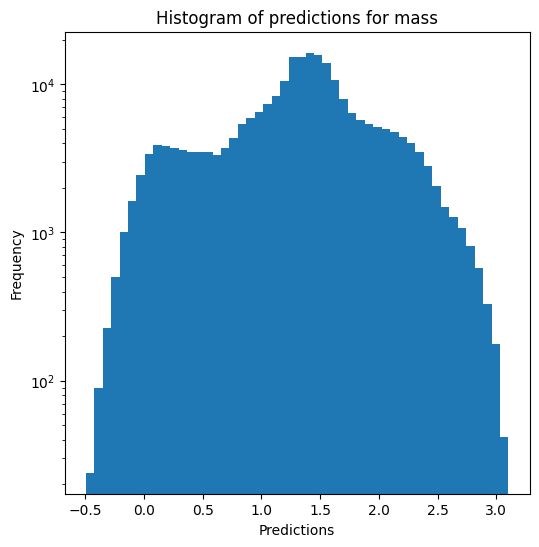

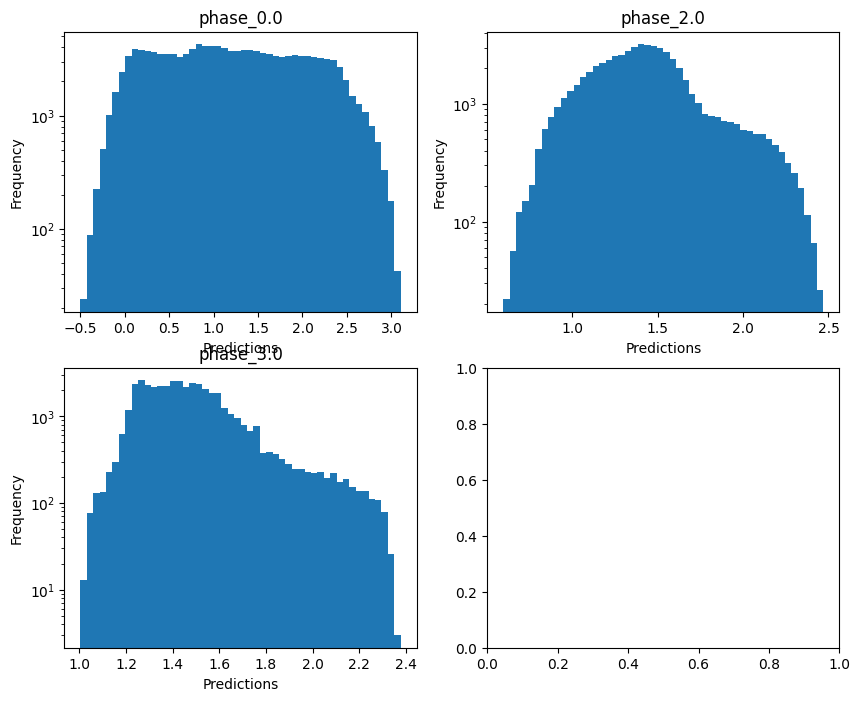

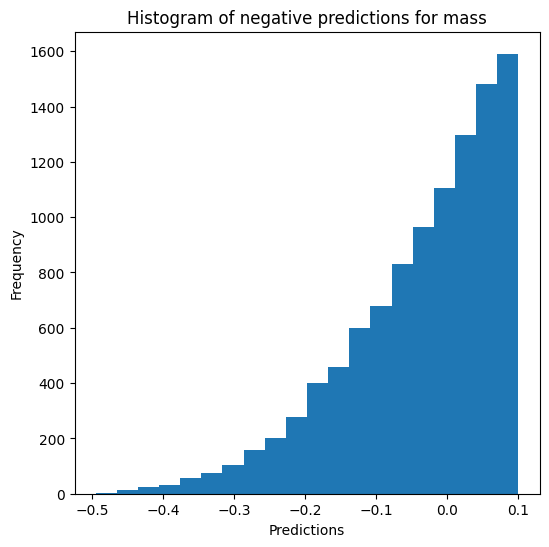


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9753521021495244
  RMSE :  0.05052817227789891
  MAE :  0.03672721002341182
  MedAE :  0.027793336685478225
  CORR :  0.9879836947112961
  MAX_ER :  0.22535086344576438
  Percentiles : 
    75th percentile :  0.049310078573483546
    90th percentile :  0.07472824897112439
    95th percentile :  0.10100600734146983
    99th percentile :  0.17735941420332046

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9833773452801731
  RMSE :  0.06202700410569032
  MAE :  0.04963890139920345
  MedAE :  0.04189326019625983
  CORR :  0.993268227885979
  MAX_ER :  0.17531844083301973
  Percentiles : 
    75th percentile :  0.07562180455351708
    90th percentile :  0.10574147447166782
    95th percentile :  0.1207467792646606
    99th percentile :  0.14045800900155725

radius results for the phase c

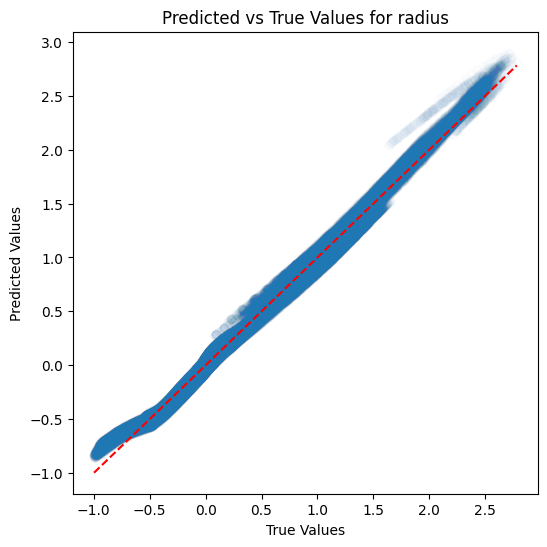

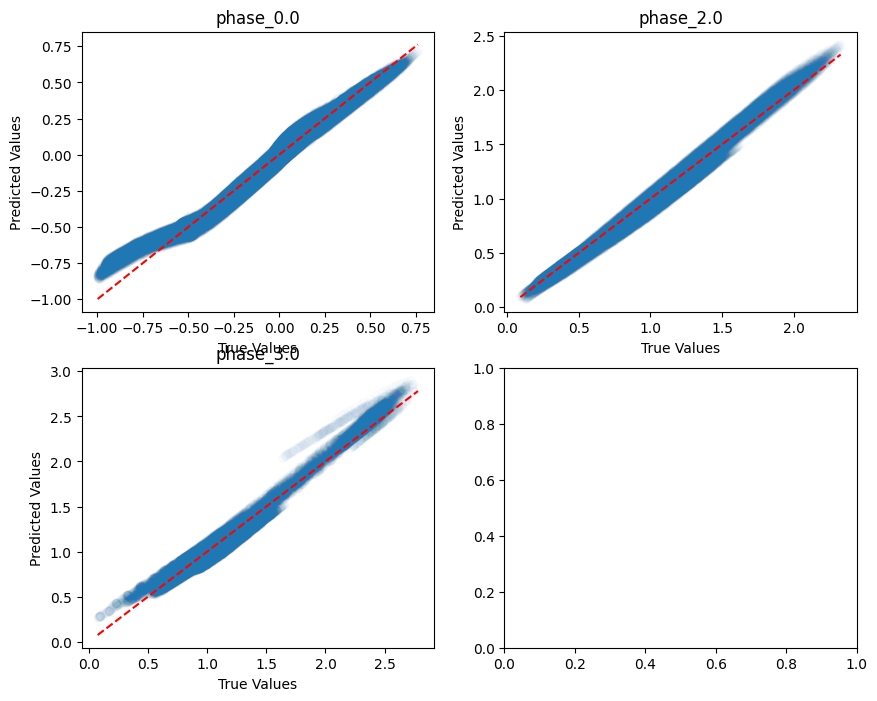

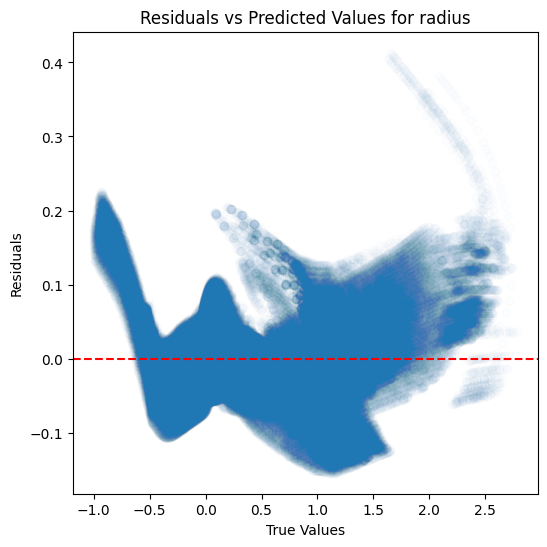

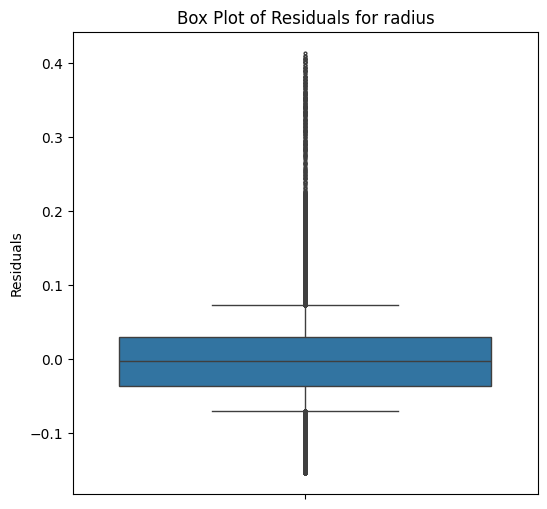

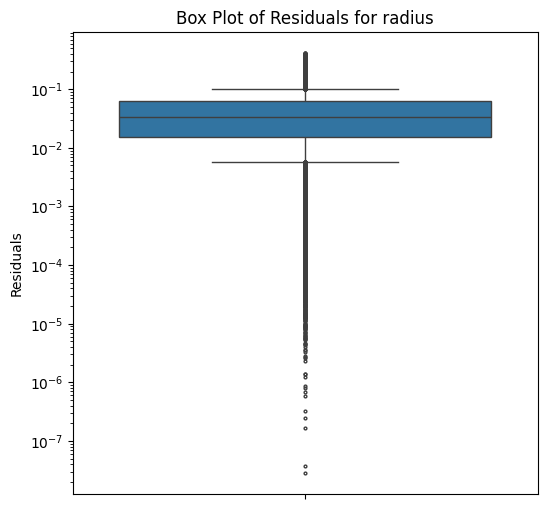

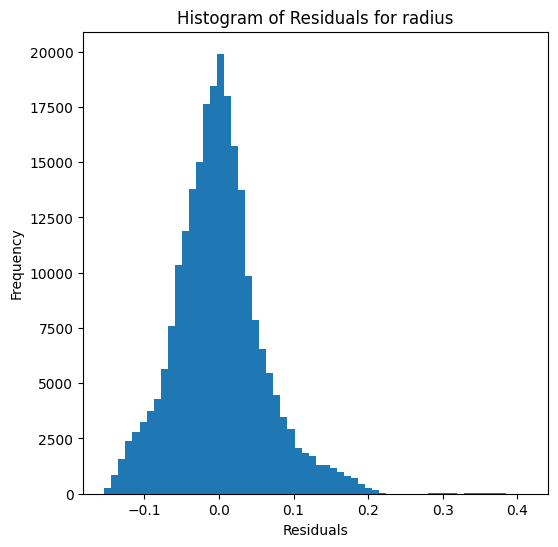

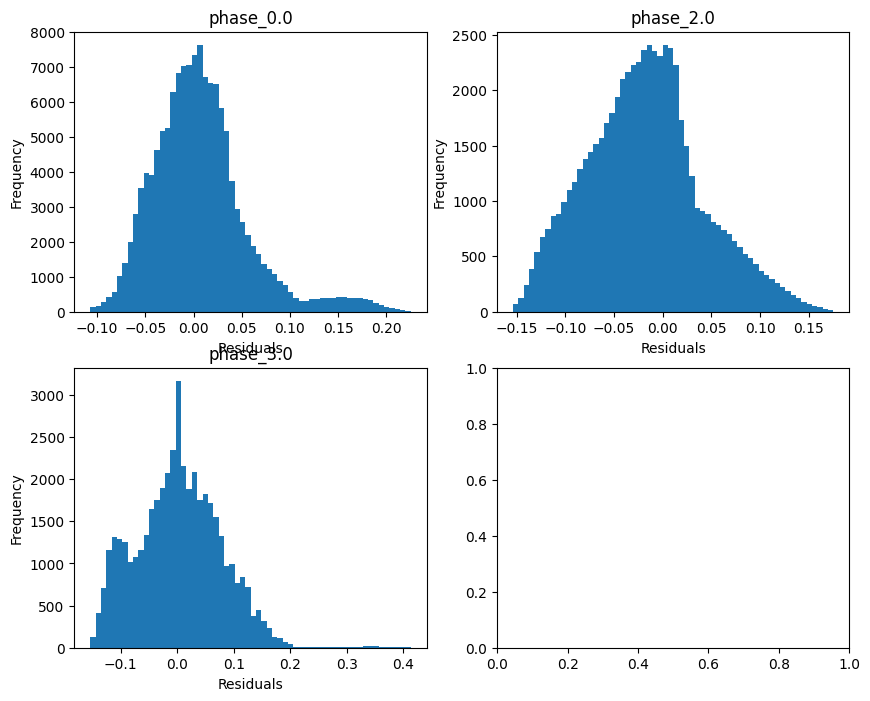

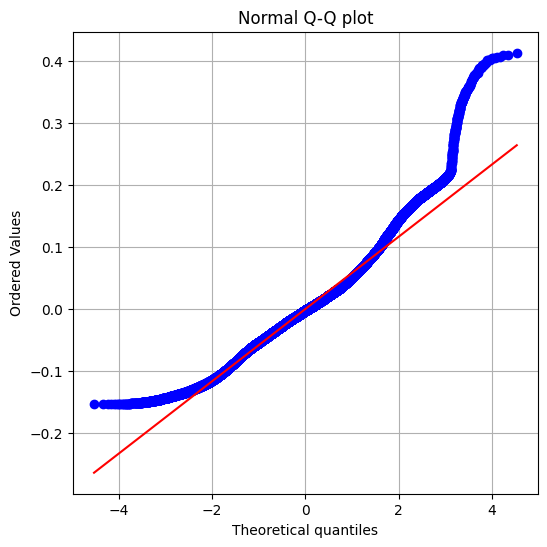

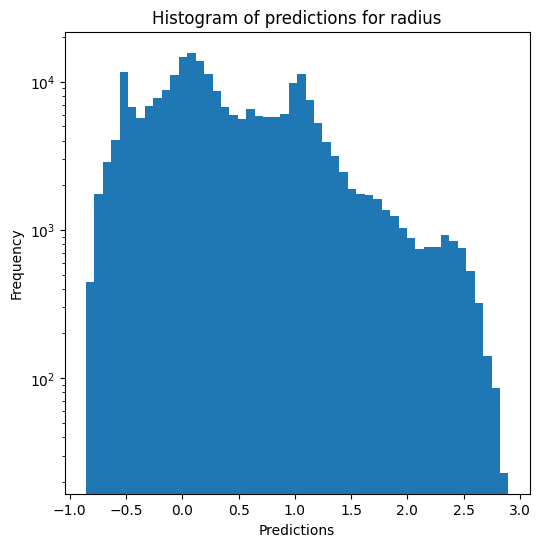

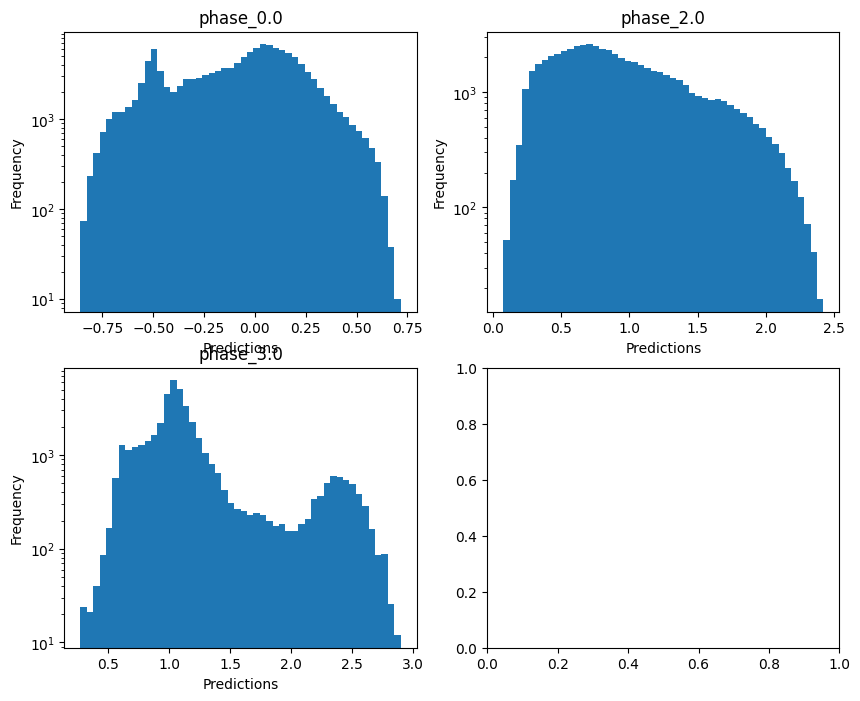

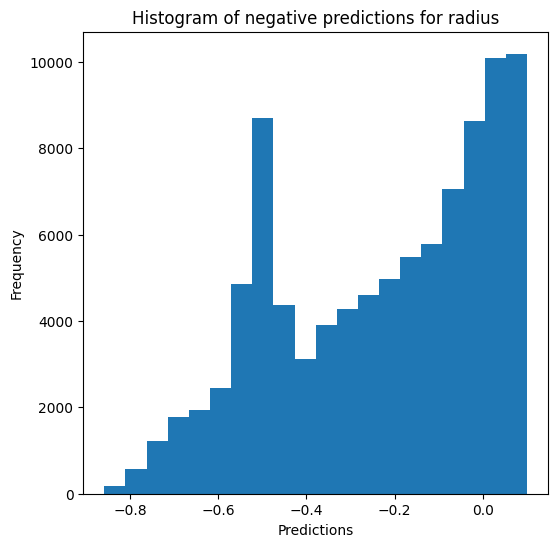

Saving results...


In [13]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show) # override=True, use_preds=False

### Decision tree

In [14]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9998026181186485
  RMSE :  0.01058791116957442
  MAE :  0.005189527805394944
  MedAE :  0.002423517797004726
  CORR :  0.9999013049827169
  MAX_ER :  0.30191034854196763
  Percentiles : 
    75th percentile :  0.005867258628839078
    90th percentile :  0.011984420428414766
    95th percentile :  0.019391465762636437
    99th percentile :  0.04078305725227508

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.999184122352797
  RMSE :  0.01788832500066743
  MAE :  0.007677760218488177
  MedAE :  0.0012066366303072895
  CORR :  0.9995972004854448
  MAX_ER :  0.4249228172899455
  Percentiles : 
    75th percentile :  0.008314936655514193
    90th percentile :  0.02498735253724782
    95th percentile :  0.03376008057240343
    99th percentil

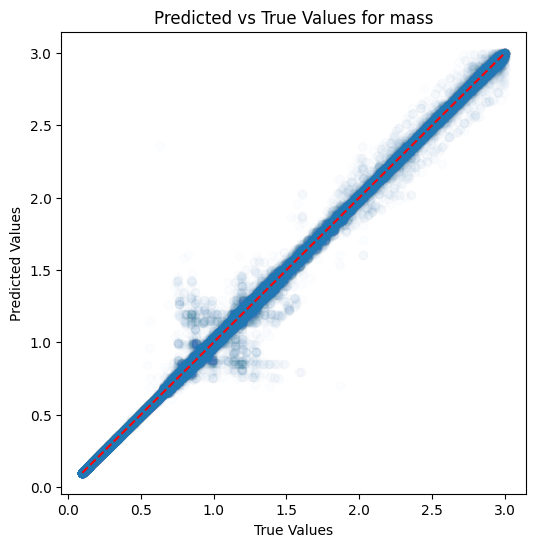

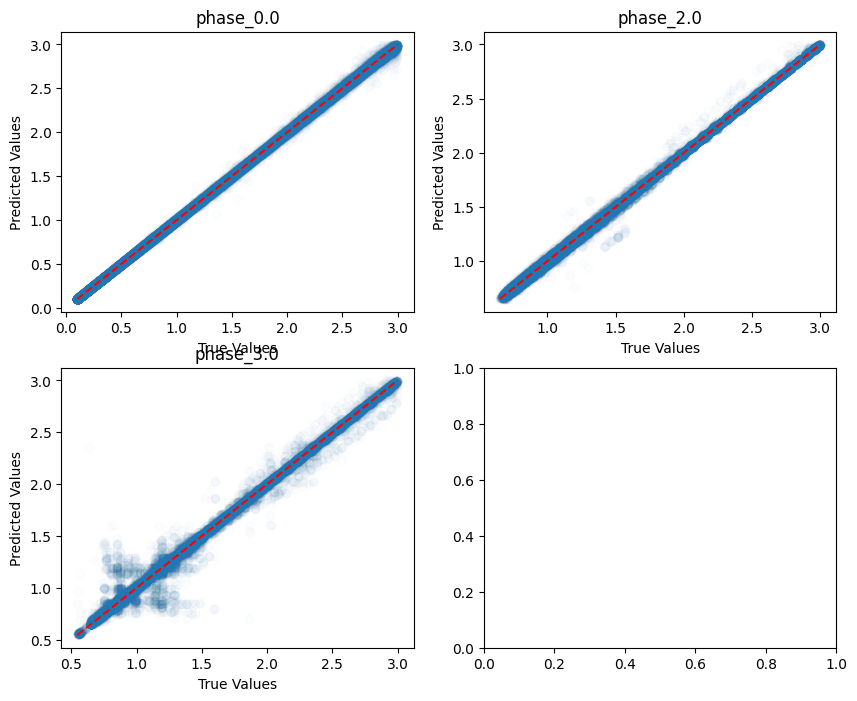

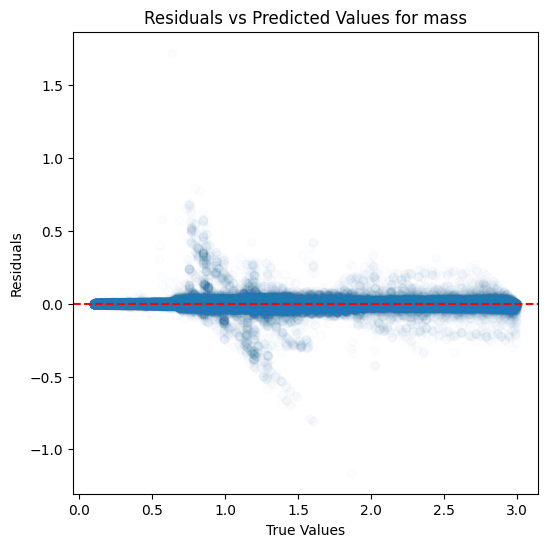

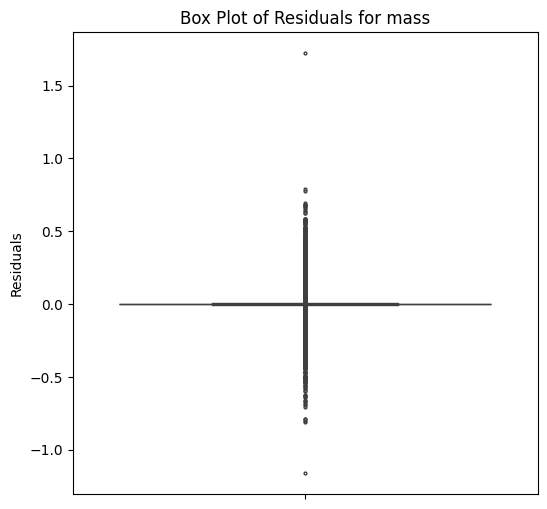

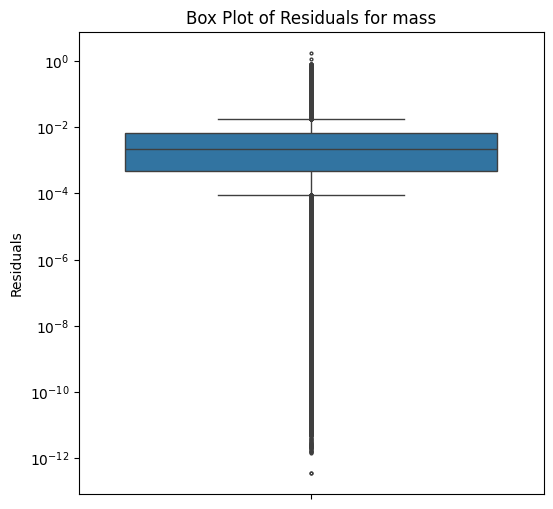

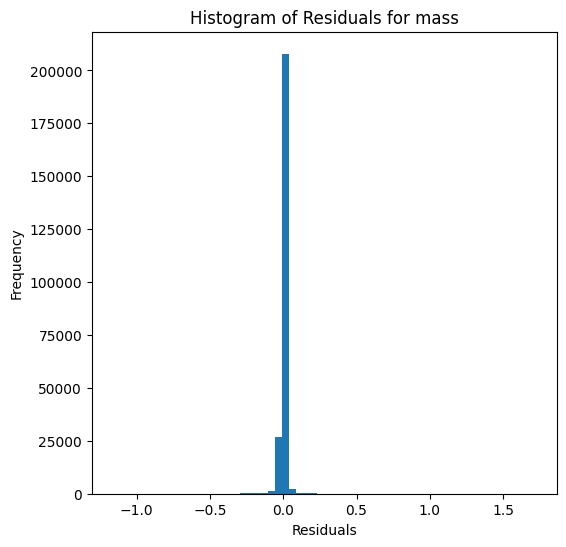

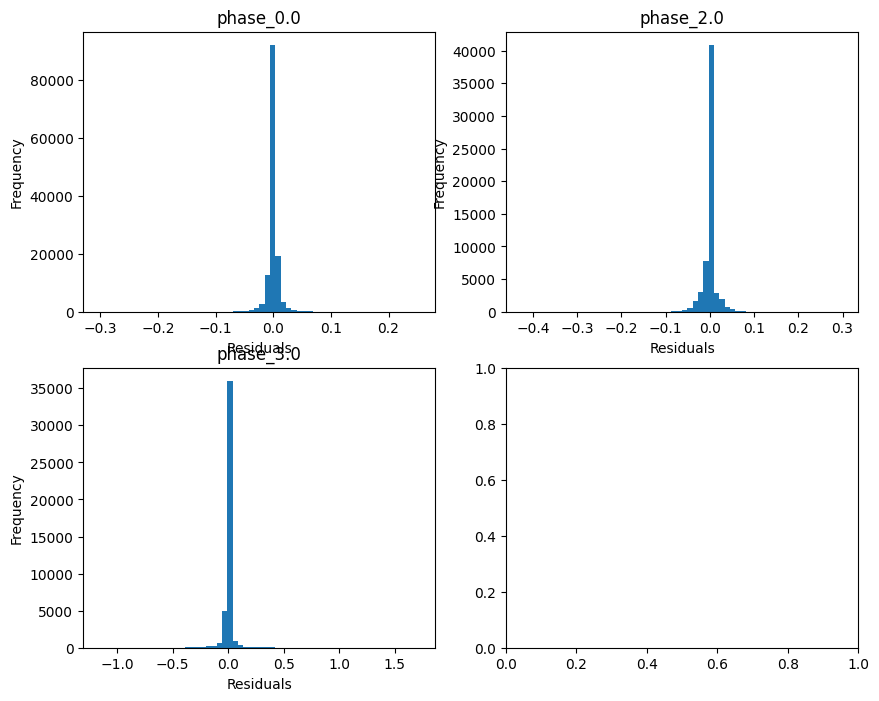

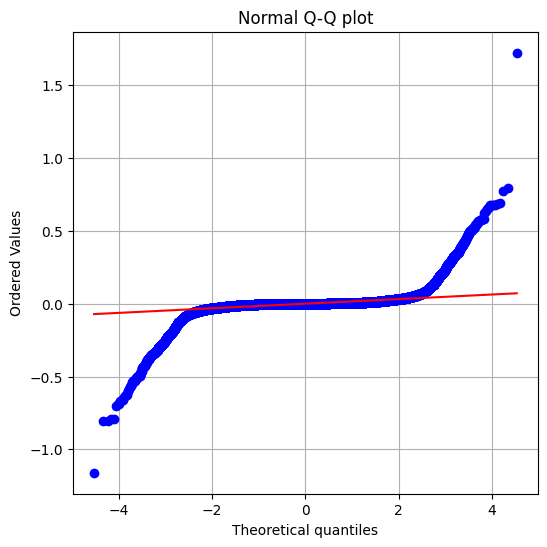

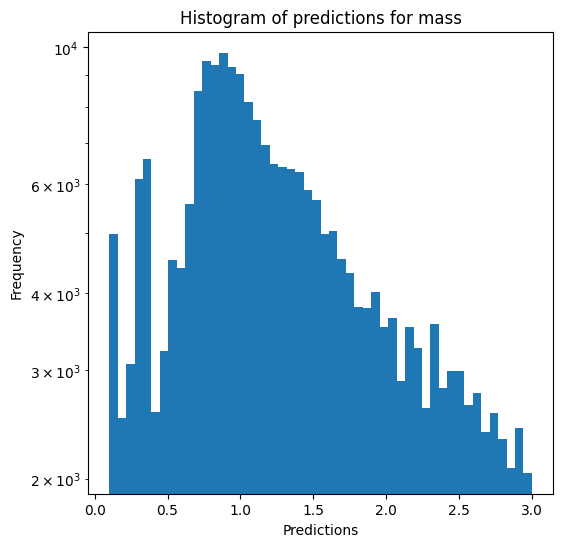

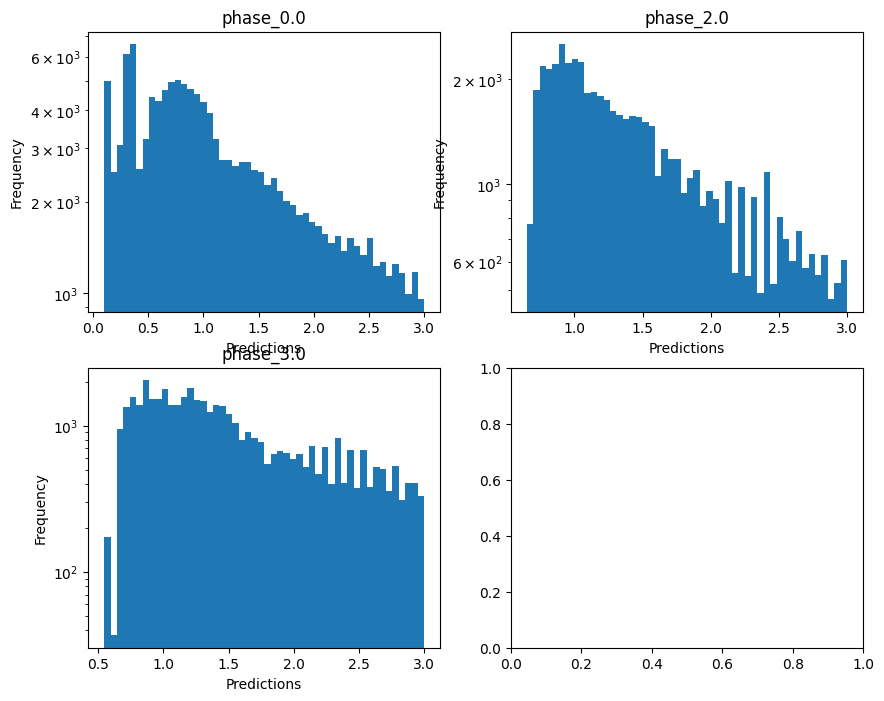

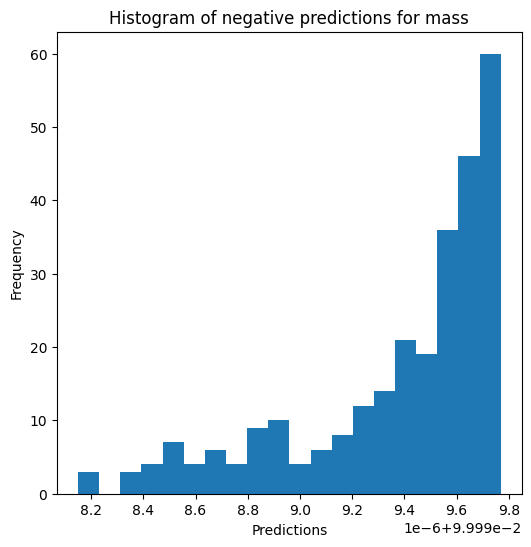


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9998249631057525
  RMSE :  0.004216027195104729
  MAE :  0.0026773446787927055
  MedAE :  0.0017762206824805497
  CORR :  0.9999125211077539
  MAX_ER :  0.0820846152073672
  Percentiles : 
    75th percentile :  0.0035080895678915036
    90th percentile :  0.005708665506989619
    95th percentile :  0.007877085209003473
    99th percentile :  0.015673576729052237

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9995465768676972
  RMSE :  0.009778358631194554
  MAE :  0.0072080327117354966
  MedAE :  0.005883932249614698
  CORR :  0.9997733155946078
  MAX_ER :  0.11968002842619757
  Percentiles : 
    75th percentile :  0.01098942003570813
    90th percentile :  0.014025477200932723
    95th percentile :  0.01672122771842538
    99th percentile :  0.029492778781431694

radius results 

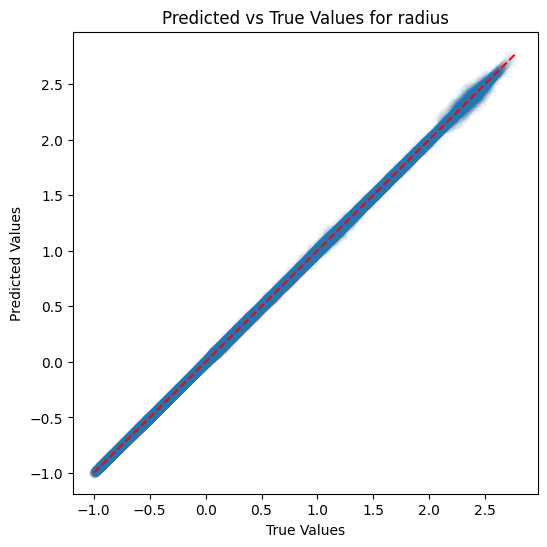

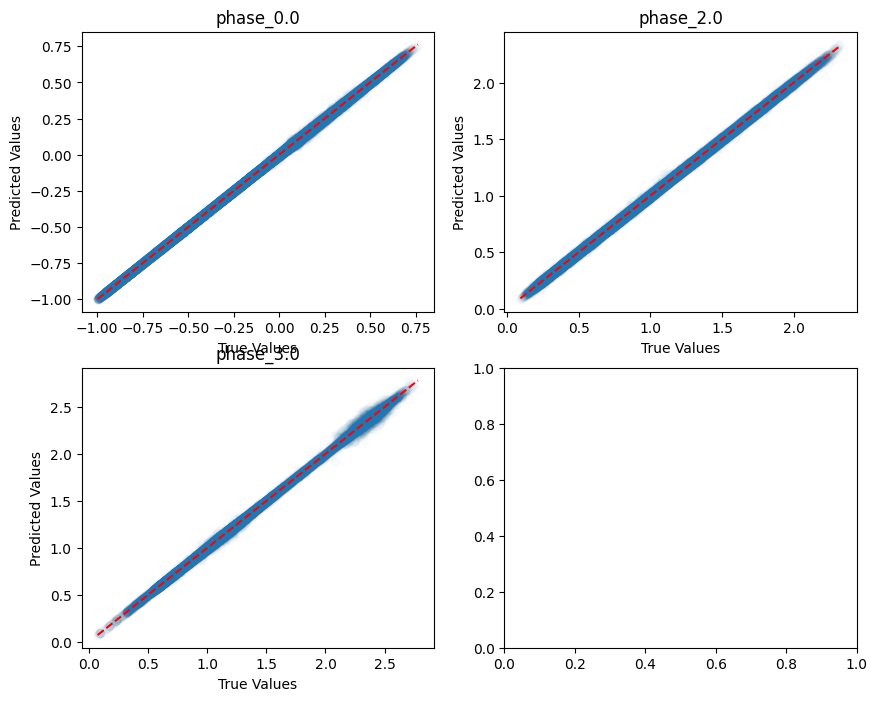

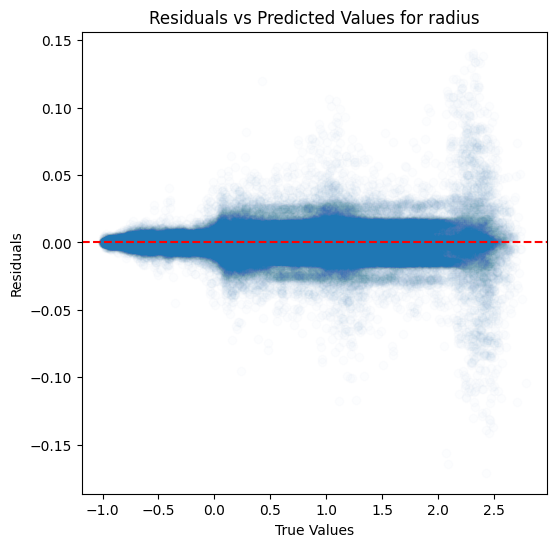

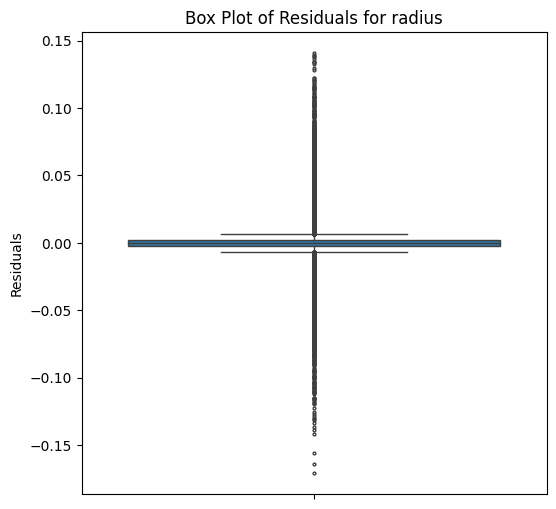

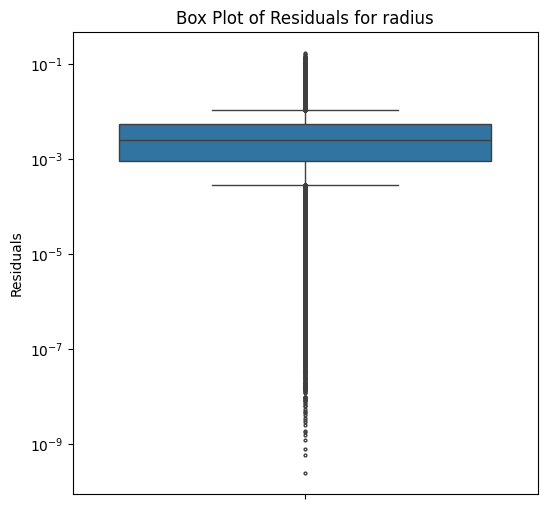

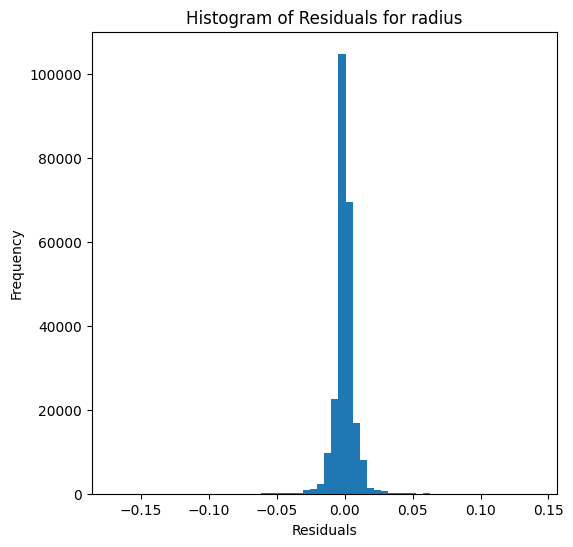

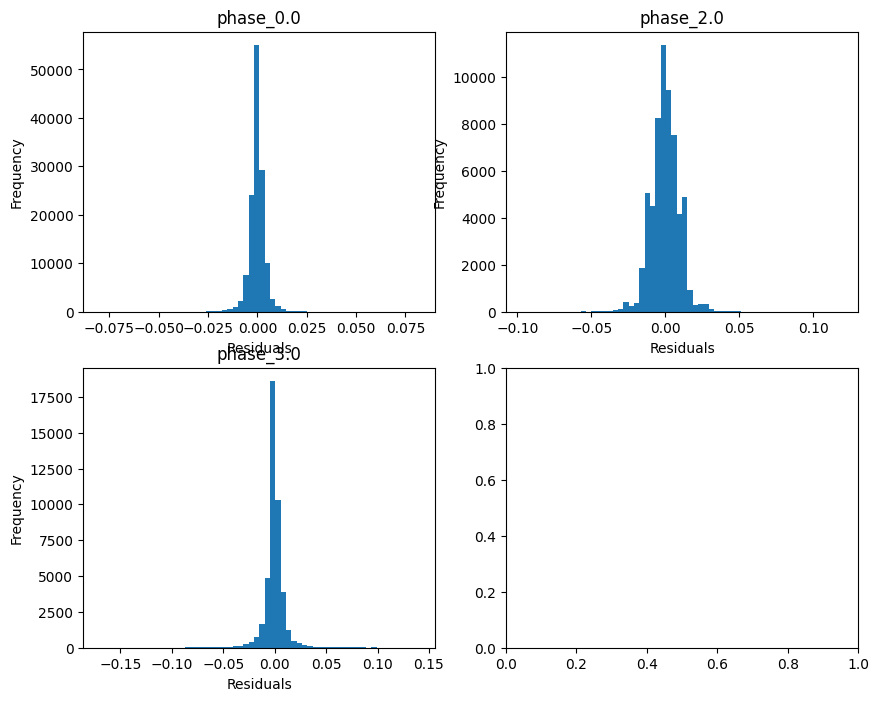

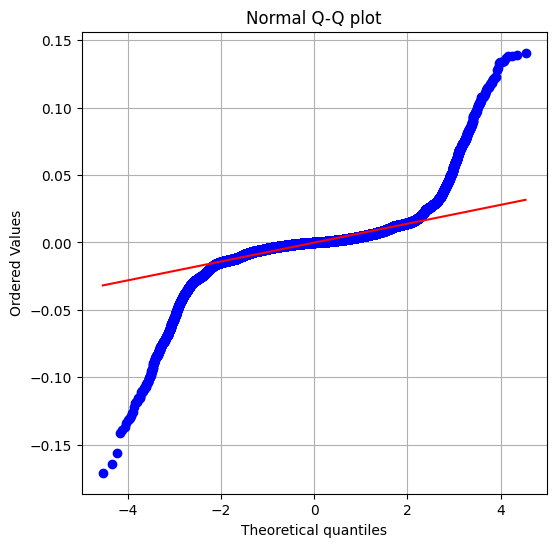

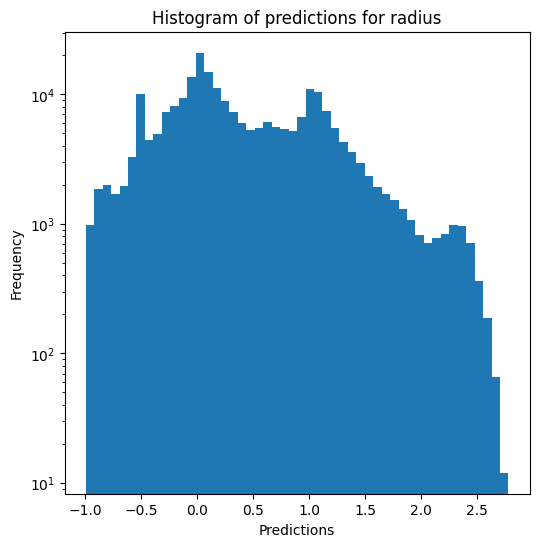

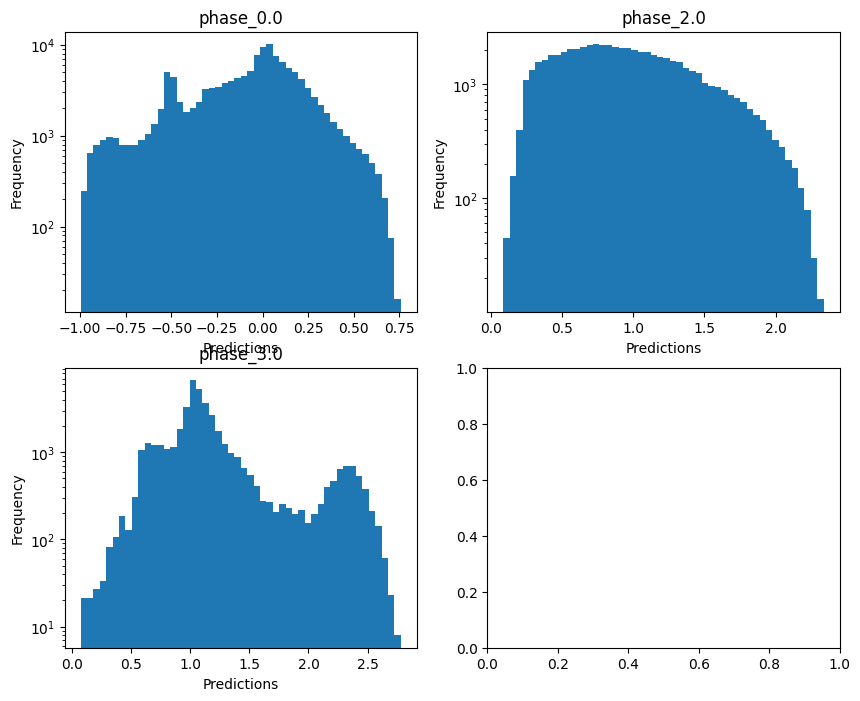

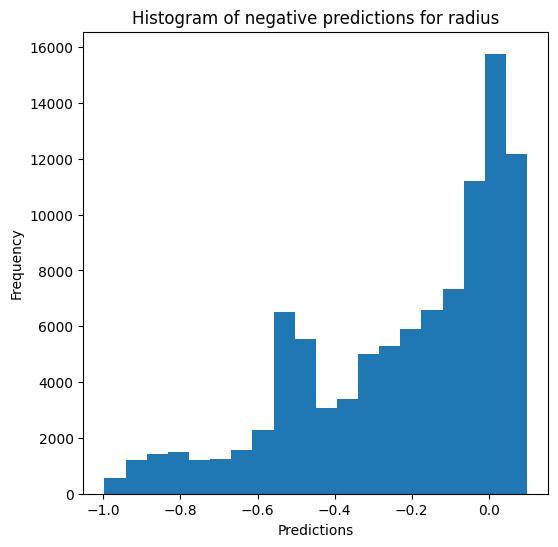

Saving results...


In [15]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### K-nearest neighbours

In [16]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9992523919405951
  RMSE :  0.020605210635016268
  MAE :  0.00965771512418596
  MedAE :  0.004403993985865218
  CORR :  0.9996303324370441
  MAX_ER :  0.3365507048572858
  Percentiles : 
    75th percentile :  0.010620926277170706
    90th percentile :  0.02180268205399956
    95th percentile :  0.03410329007869925
    99th percentile :  0.09181234482205852

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9991895200338567
  RMSE :  0.01784945107156771
  MAE :  0.00887191365911853
  MedAE :  0.004881357314376444
  CORR :  0.9996113621195056
  MAX_ER :  0.30041676225470537
  Percentiles : 
    75th percentile :  0.01119925126840915
    90th percentile :  0.021266252962711896
    95th percentile :  0.030652523577322732
 

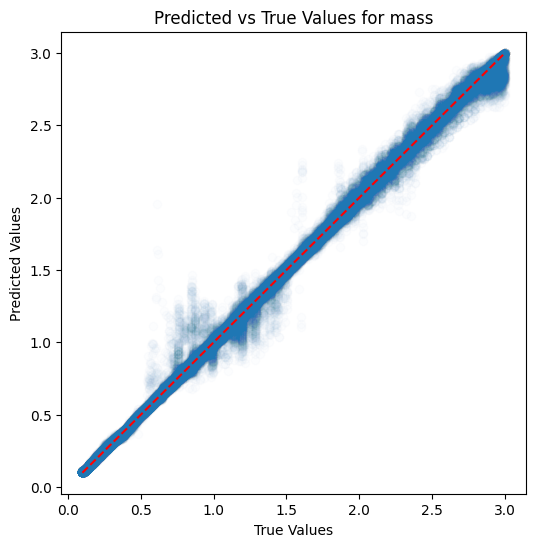

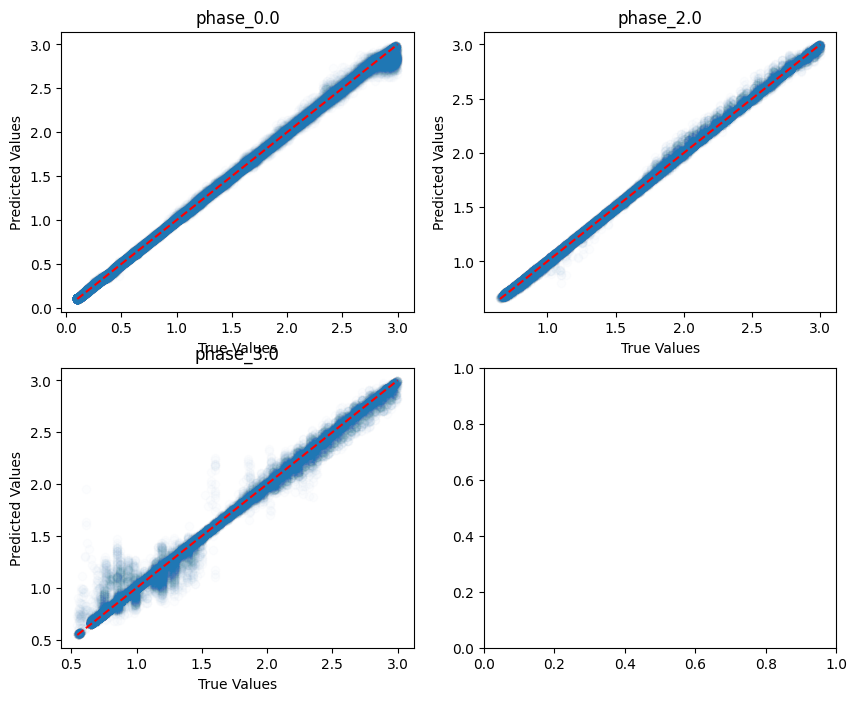

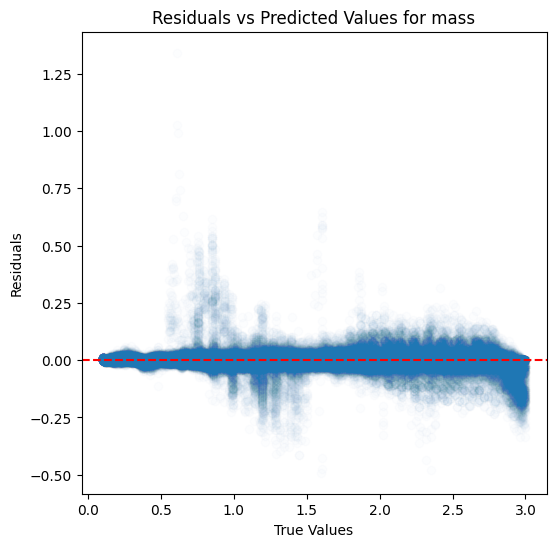

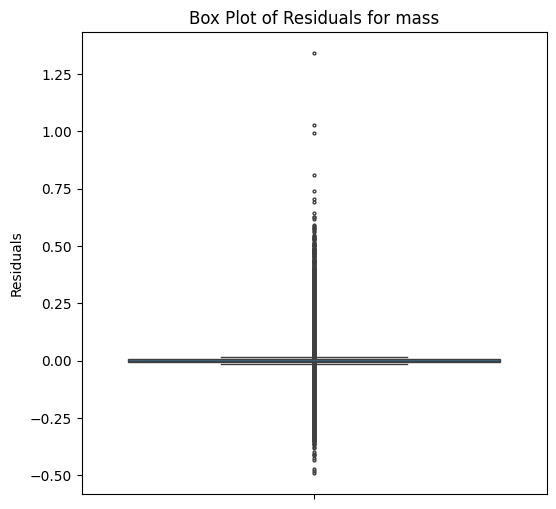

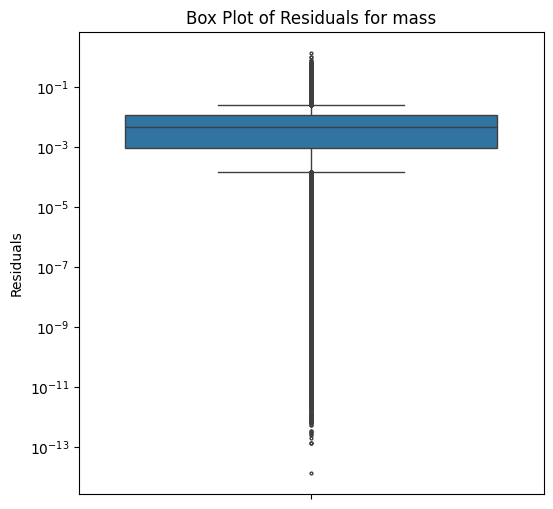

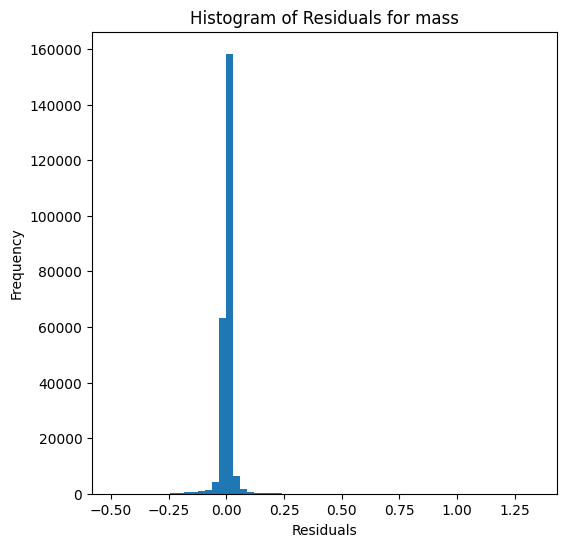

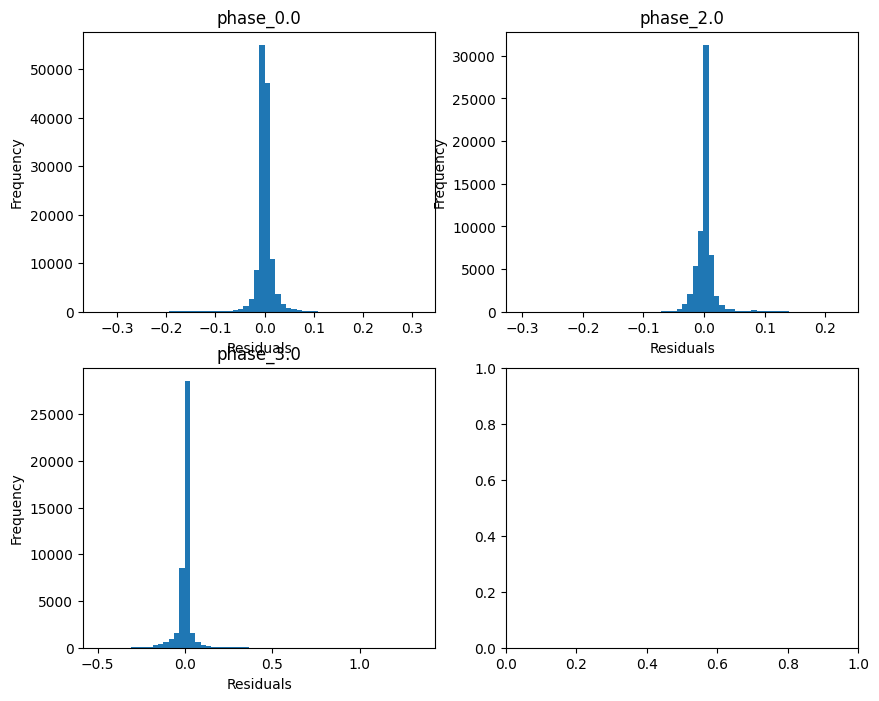

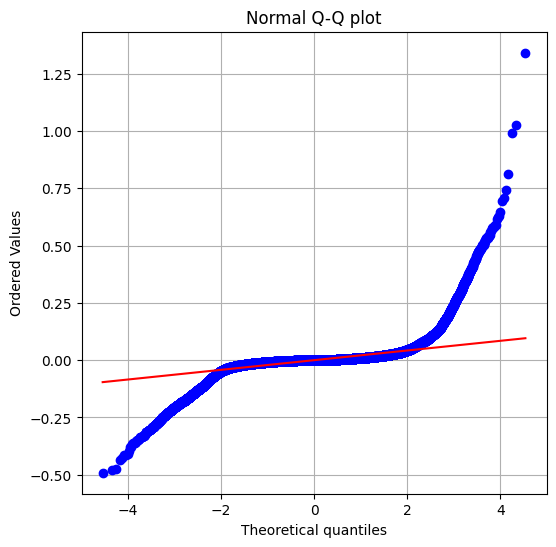

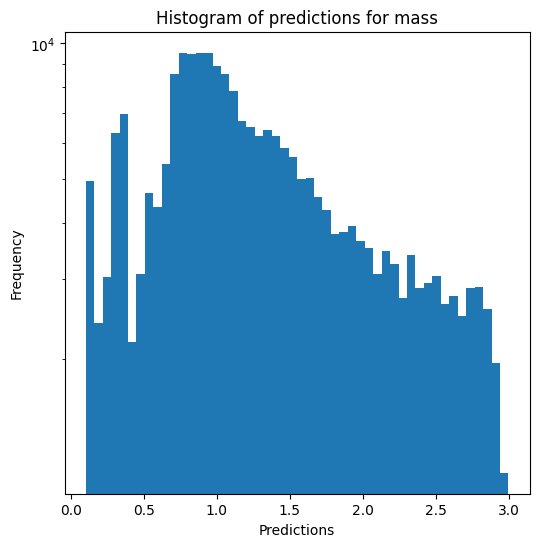

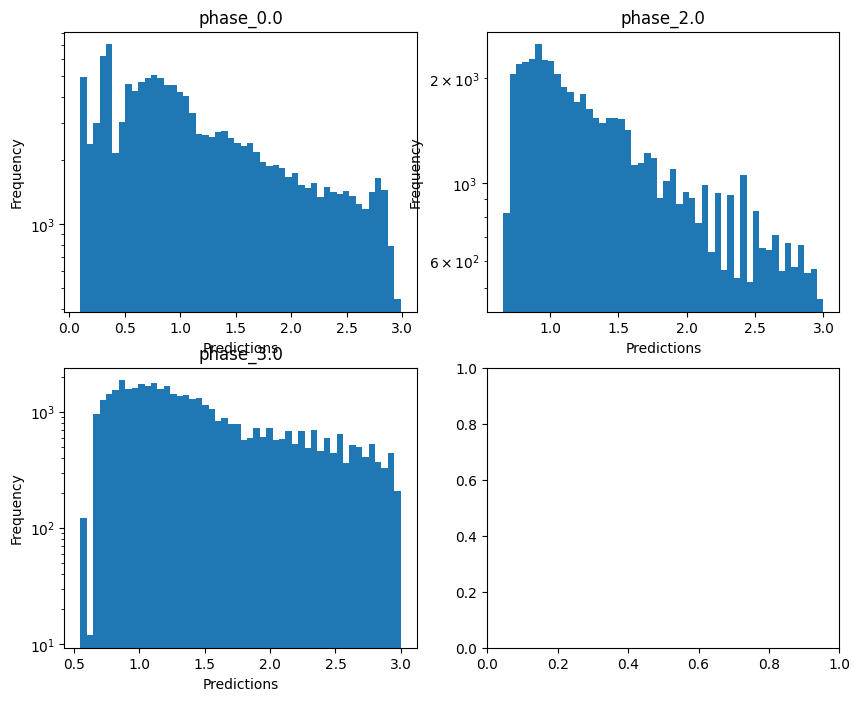


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9996571642468787
  RMSE :  0.005898775668760159
  MAE :  0.0038503467937312493
  MedAE :  0.0023860358871441306
  CORR :  0.999830888291084
  MAX_ER :  0.0944919451357491
  Percentiles : 
    75th percentile :  0.004836642537584847
    90th percentile :  0.009058973487606077
    95th percentile :  0.012723795298660632
    99th percentile :  0.021788180206897458

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9998807428184813
  RMSE :  0.005014845390347061
  MAE :  0.0038563851807527517
  MedAE :  0.0030701641787285183
  CORR :  0.9999404528865401
  MAX_ER :  0.0695902352096498
  Percentiles : 
    75th percentile :  0.005280661706050016
    90th percentile :  0.008232139075678796
    95th percentile :  0.010052538992501914
    99th percentile :  0.014087159511477765

radius results 

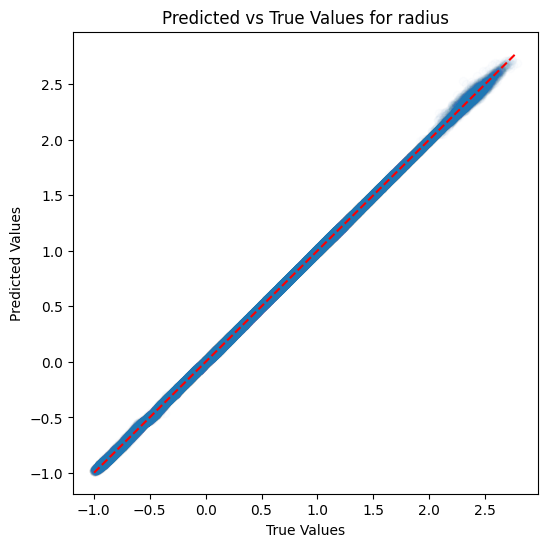

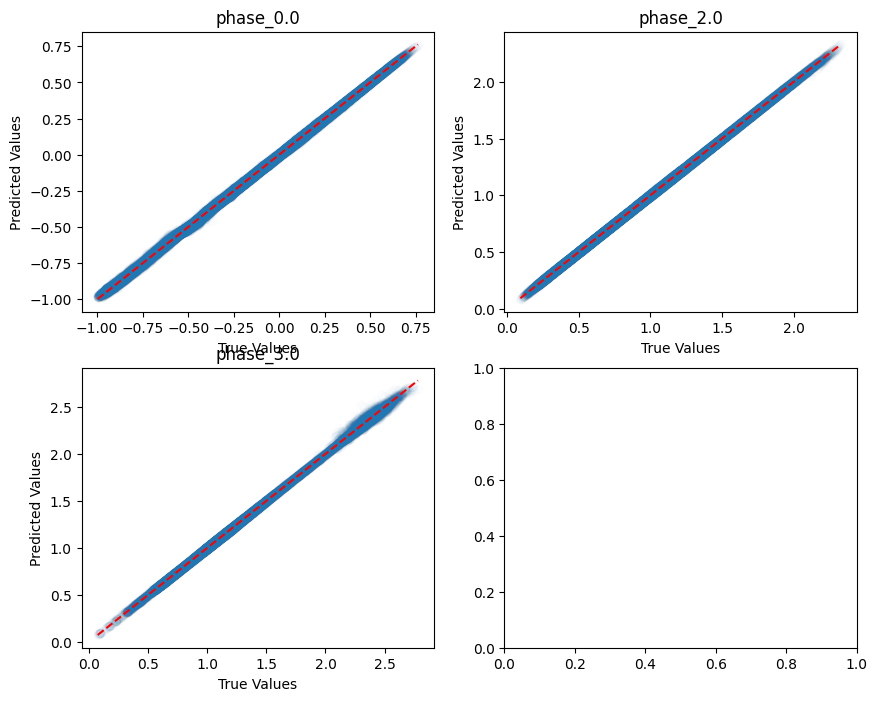

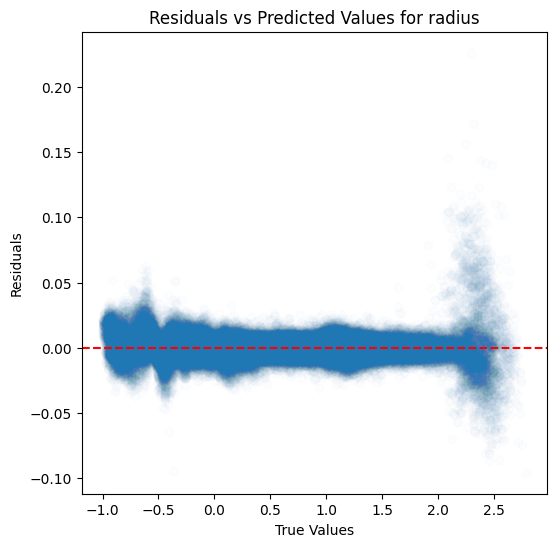

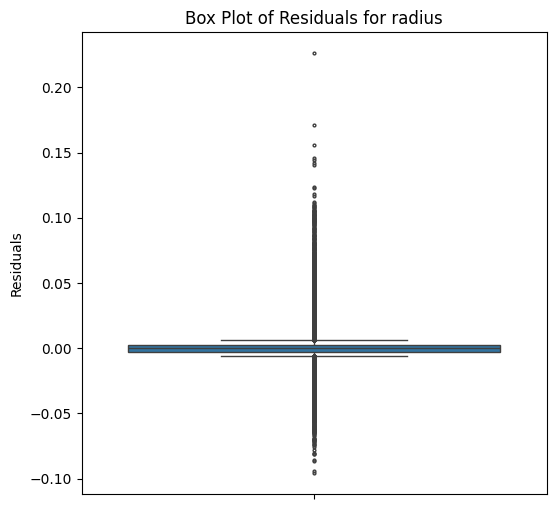

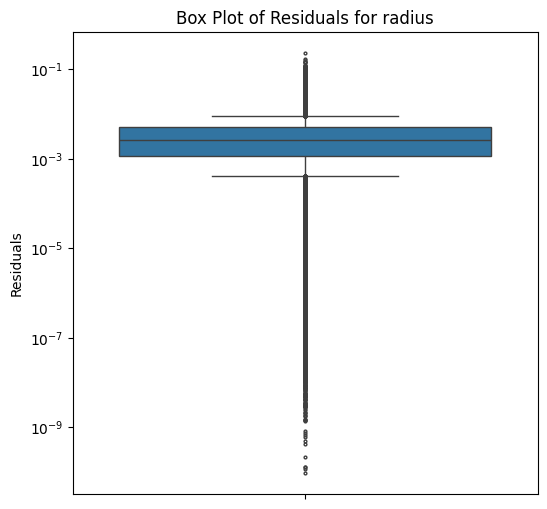

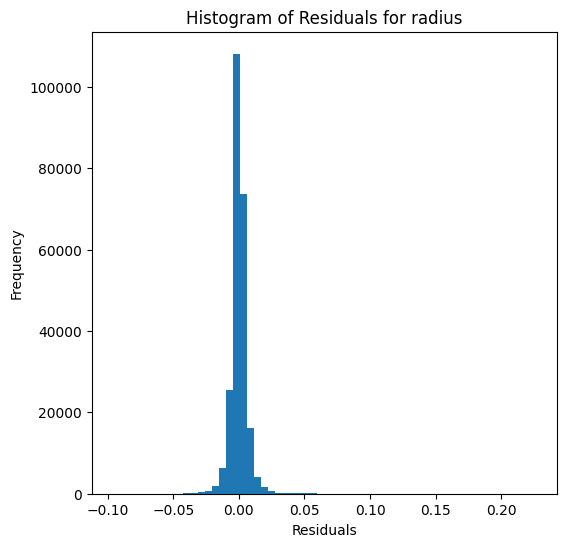

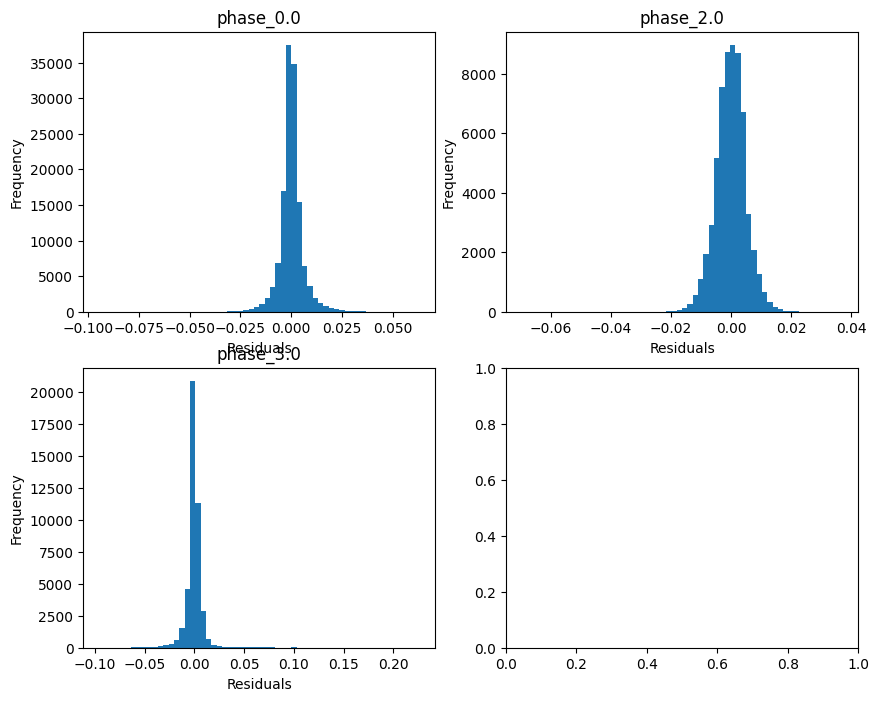

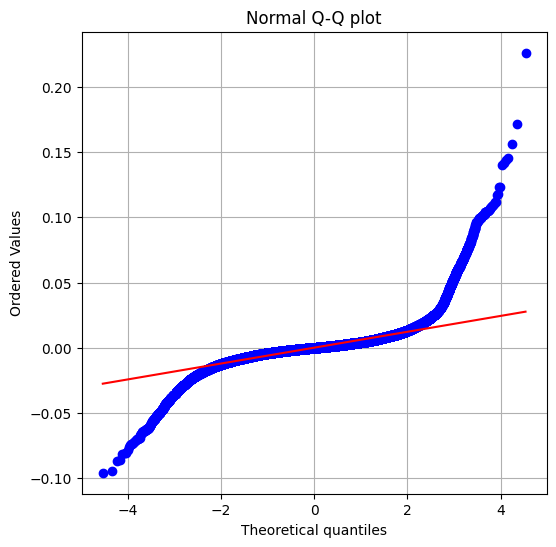

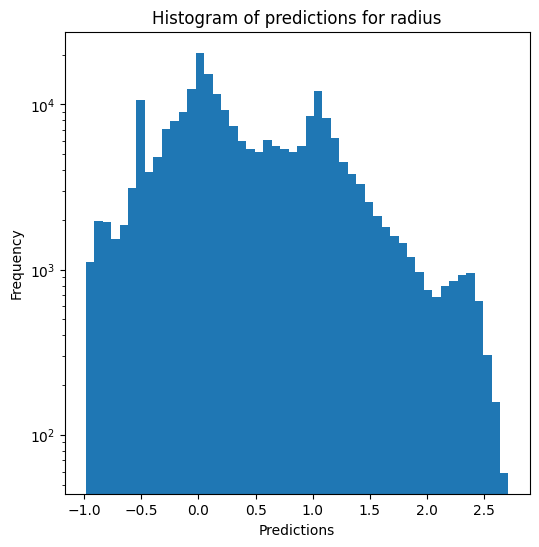

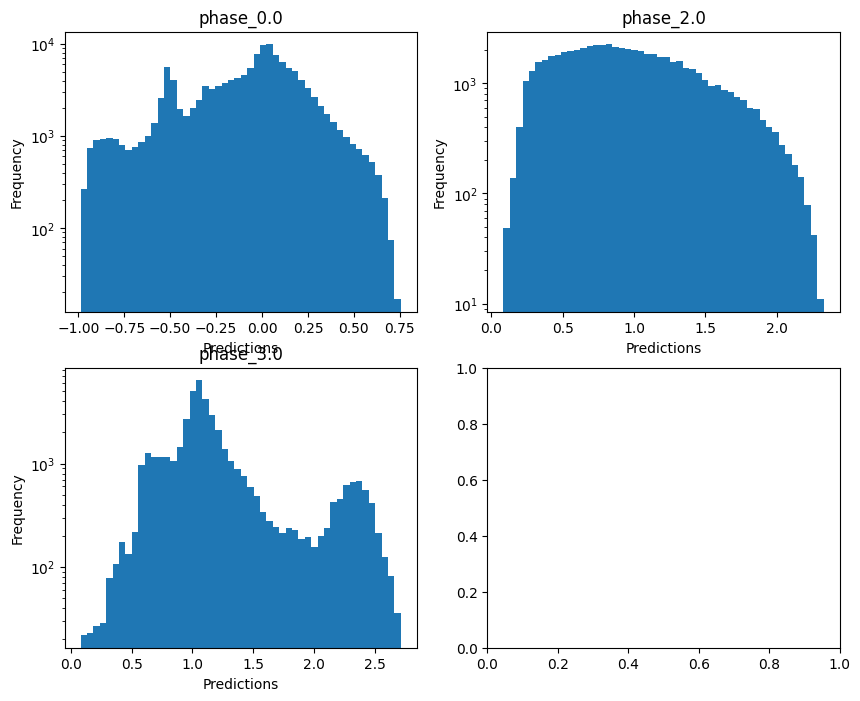

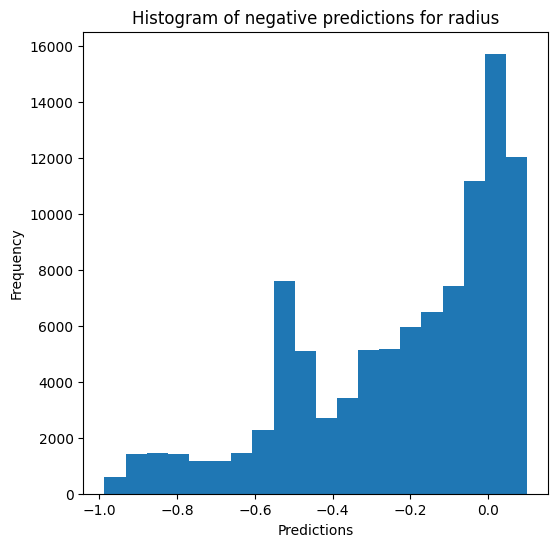

Saving results...


In [17]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show)

### Random forests

In [18]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9999474983734866
  RMSE :  0.005461256540132286
  MAE :  0.0027144181629888044
  MedAE :  0.0013043118316485303
  CORR :  0.9999737782832668
  MAX_ER :  0.23291342282086358
  Percentiles : 
    75th percentile :  0.003110601675337138
    90th percentile :  0.006336502726882634
    95th percentile :  0.009603449185788713
    99th percentile :  0.021710632580407414

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9996443438393721
  RMSE :  0.011810299707038284
  MAE :  0.0069938190198075775
  MedAE :  0.004403188597807084
  CORR :  0.9998265900407789
  MAX_ER :  0.2138228536625688
  Percentiles : 
    75th percentile :  0.009209393113918607
    90th percentile :  0.015757301052629957
    95th percentile :  0.02121785848215013
    99th pe

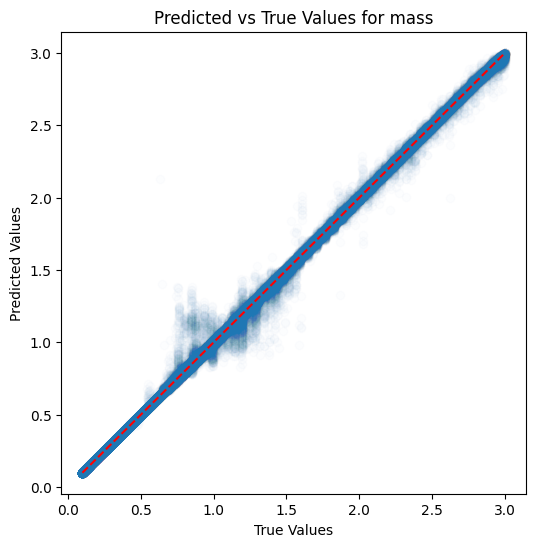

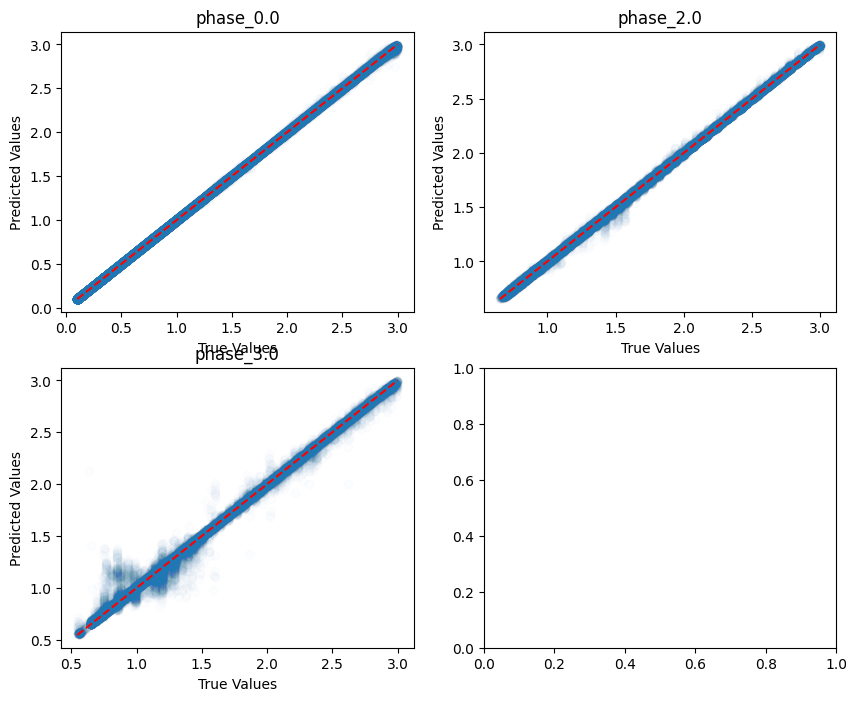

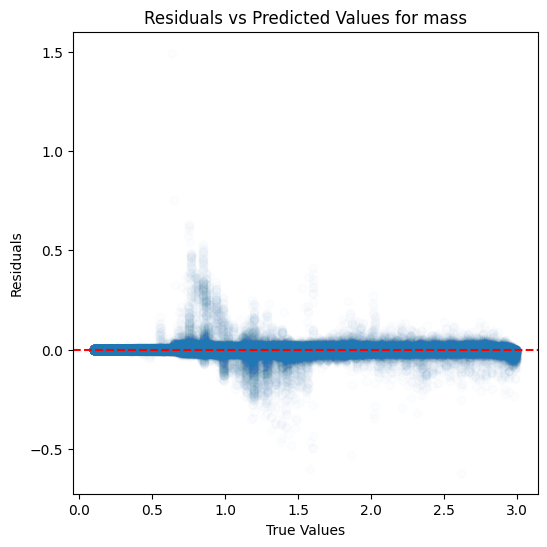

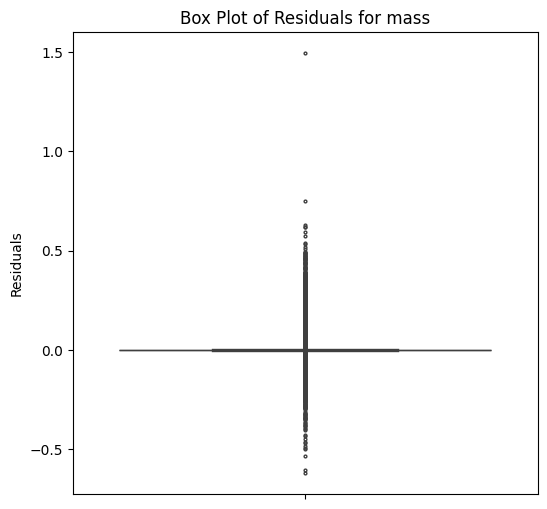

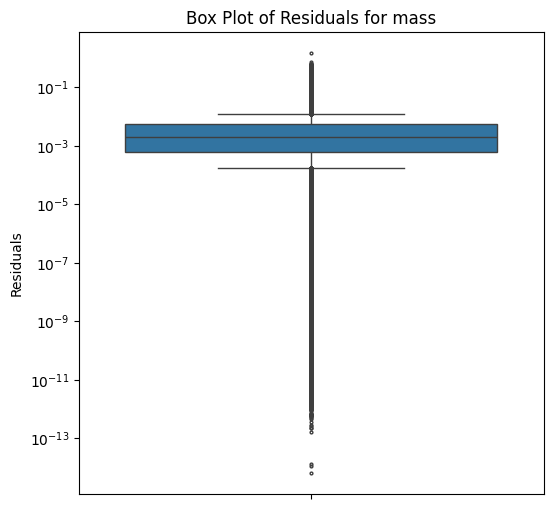

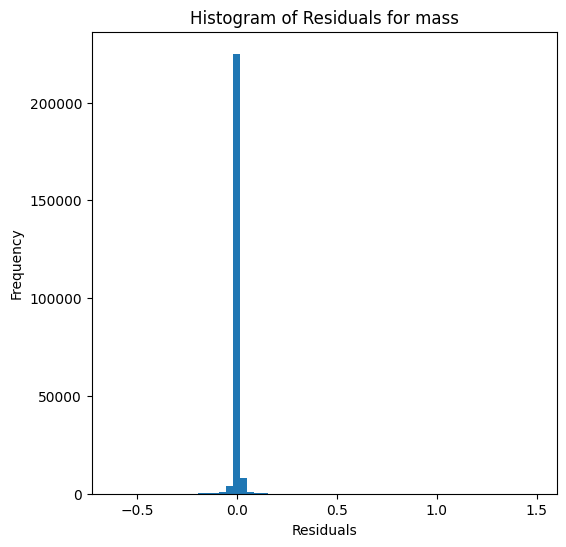

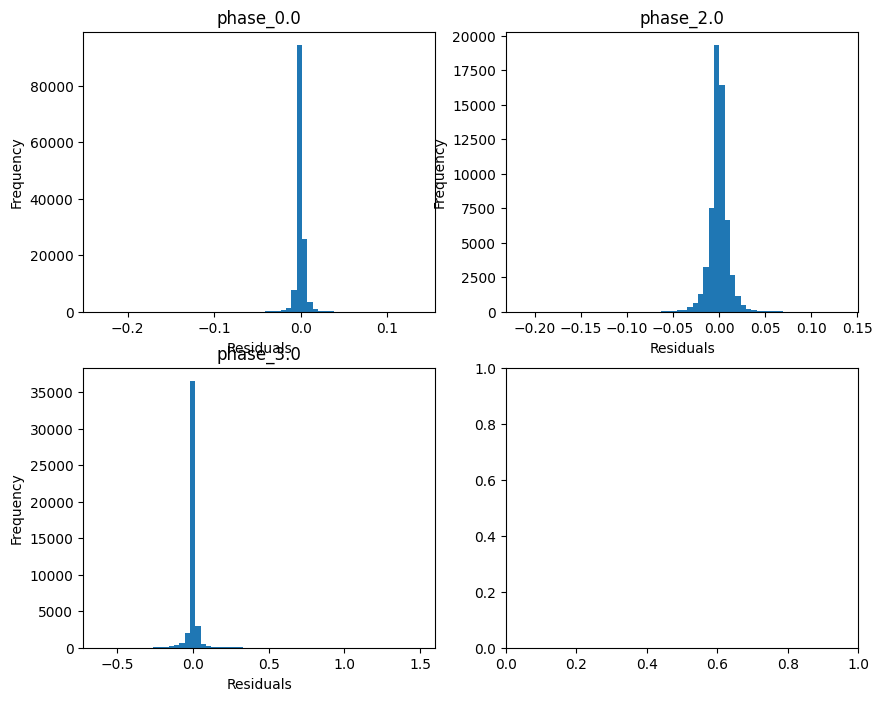

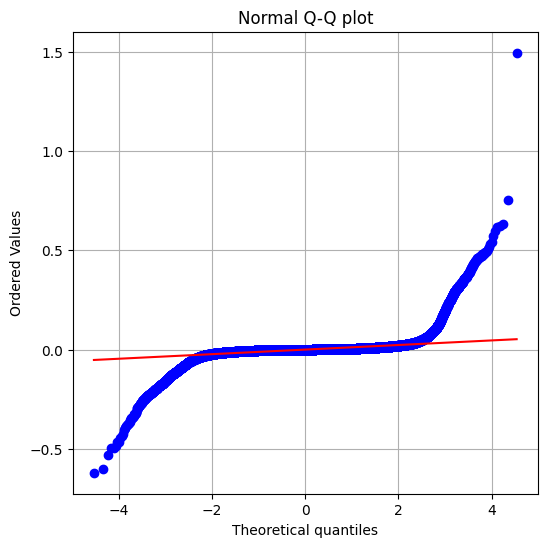

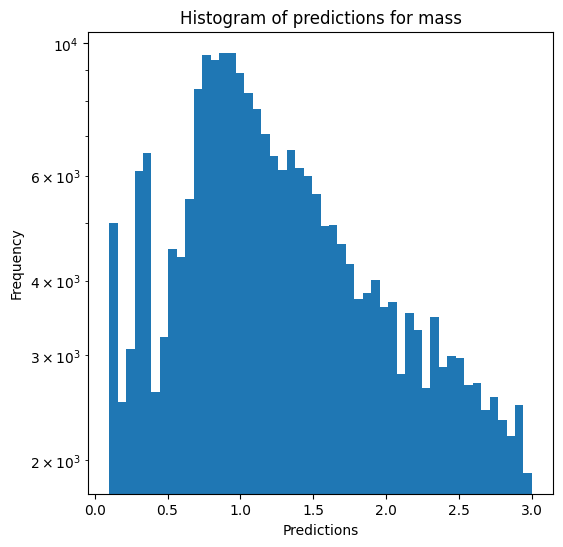

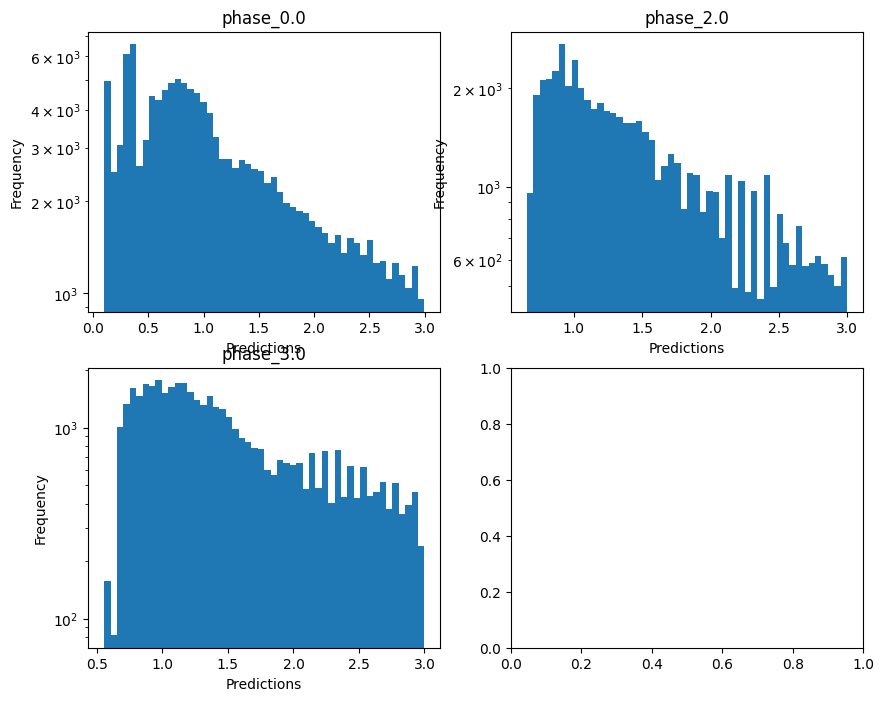

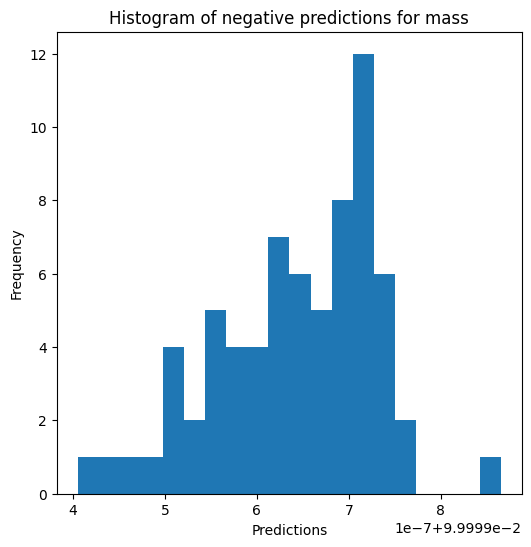


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9999678953910232
  RMSE :  0.0018091715896806611
  MAE :  0.001115560960938204
  MedAE :  0.0006852310490122401
  CORR :  0.9999840579307431
  MAX_ER :  0.04337867787178439
  Percentiles : 
    75th percentile :  0.0014190191926465728
    90th percentile :  0.0025471205057329906
    95th percentile :  0.0035551692884724134
    99th percentile :  0.006555802547362614

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9999301508060892
  RMSE :  0.0038391261788879322
  MAE :  0.0026871629570089433
  MedAE :  0.0018655376725698058
  CORR :  0.9999650748236046
  MAX_ER :  0.044940092432407486
  Percentiles : 
    75th percentile :  0.0036598490740741285
    90th percentile :  0.0060891924375261475
    95th percentile :  0.007925985092796108
    99th percentile :  0.012392624909360661

radiu

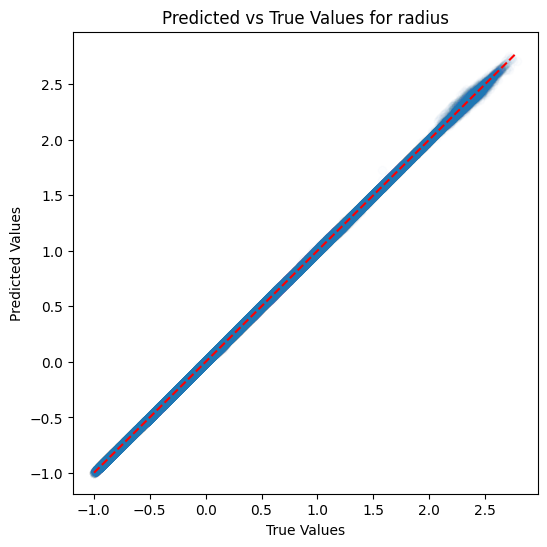

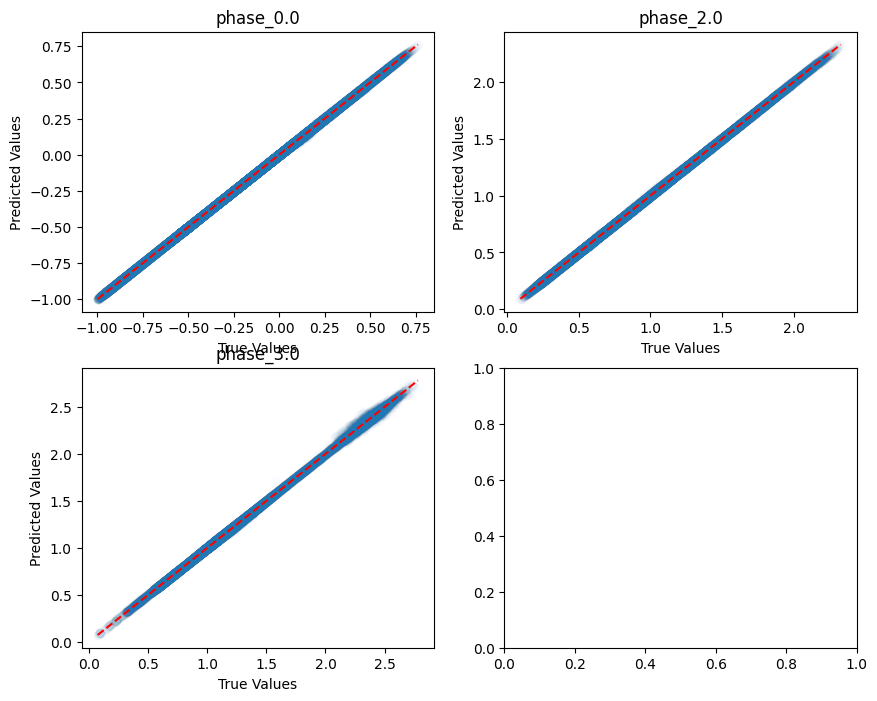

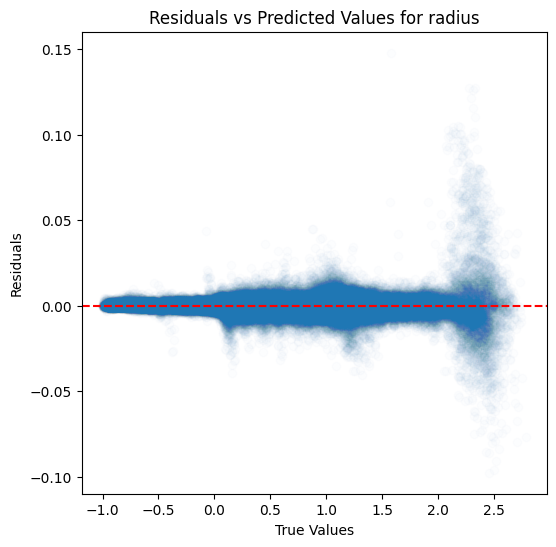

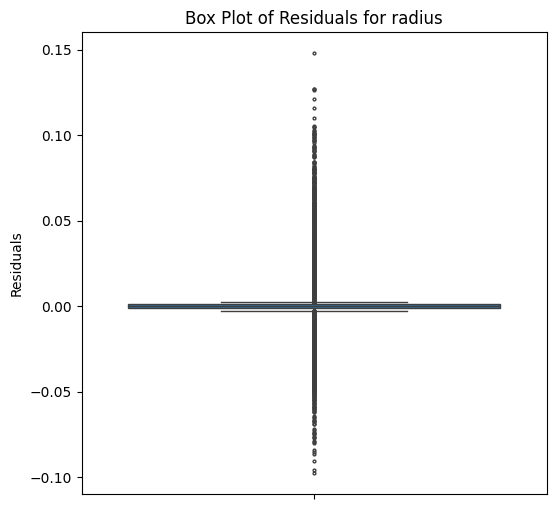

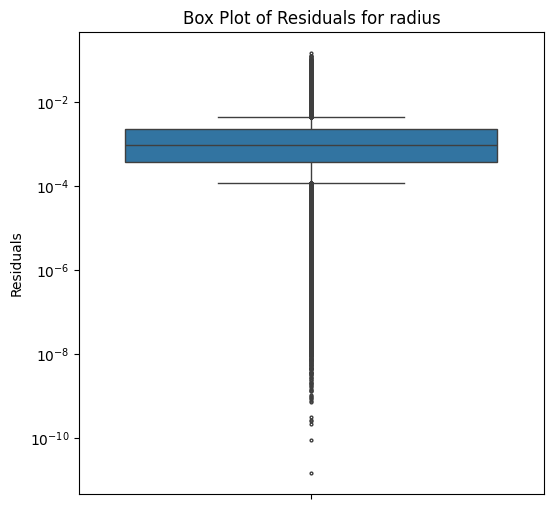

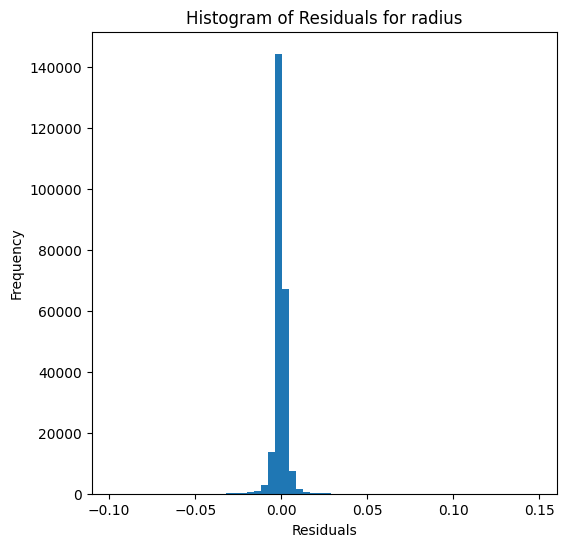

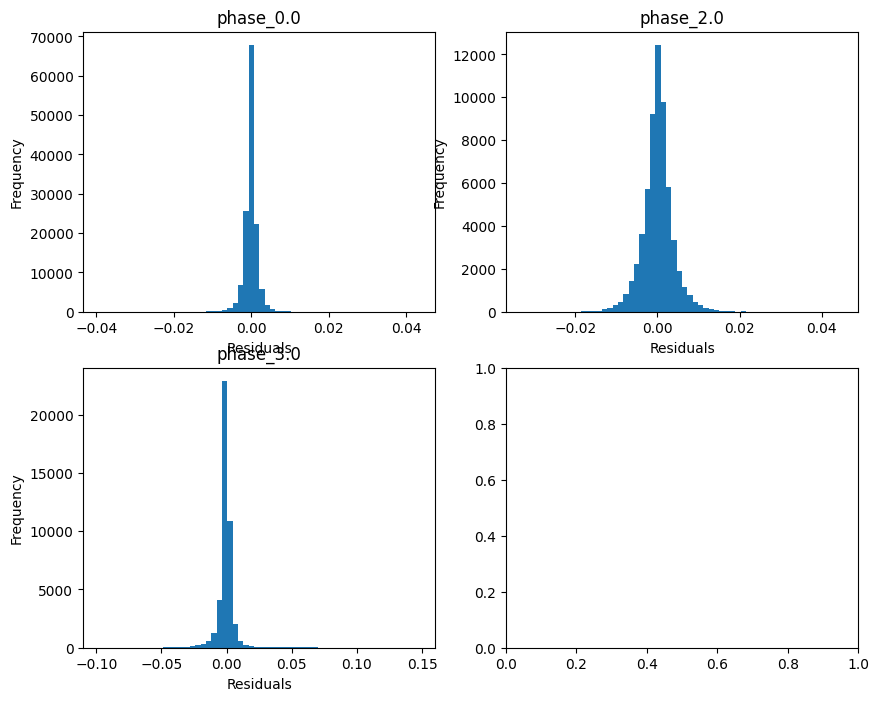

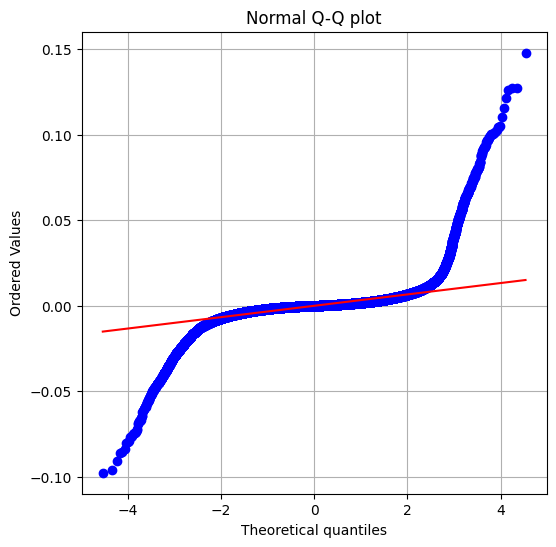

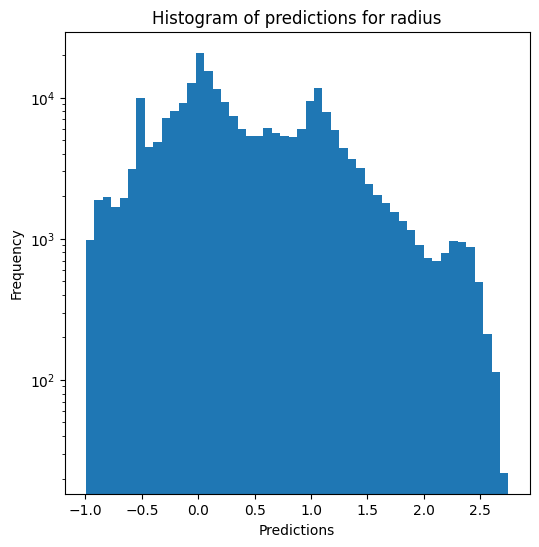

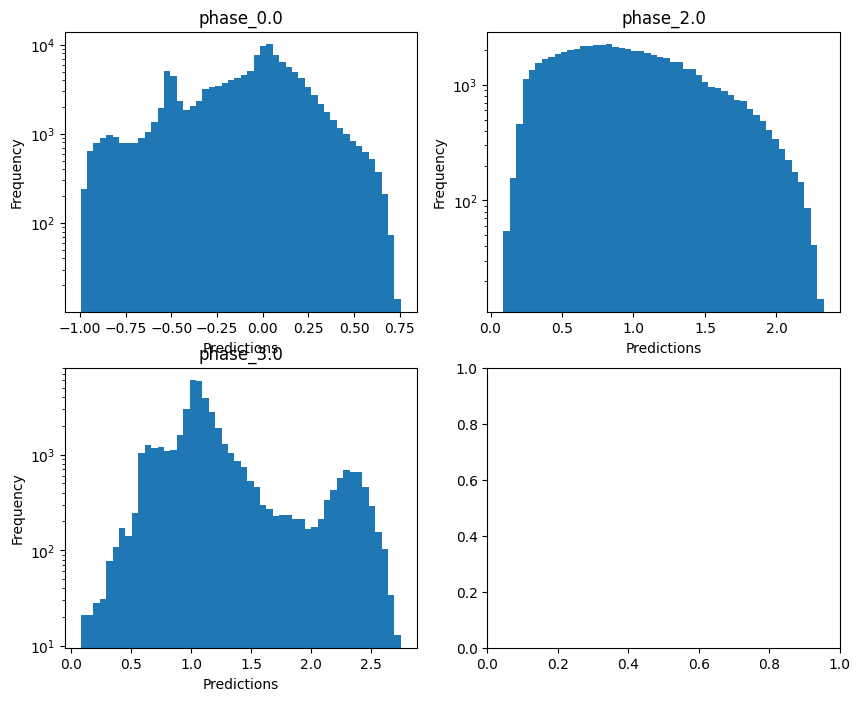

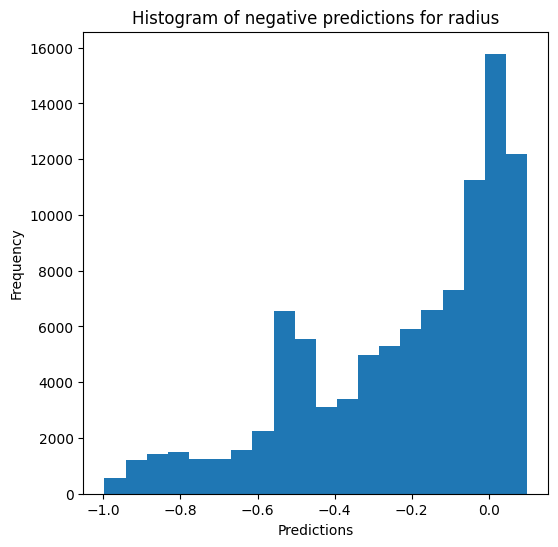

Saving results...


In [19]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### XGBoost

In [20]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9990479465037205
  RMSE :  0.02325255882081821
  MAE :  0.01566983795125544
  MedAE :  0.010457313701625393
  CORR :  0.9995239924982884
  MAX_ER :  0.26696837093627046
  Percentiles : 
    75th percentile :  0.020549780543402923
    90th percentile :  0.03539142965120543
    95th percentile :  0.04828132570535179
    99th percentile :  0.08280370639207071

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9991669639635611
  RMSE :  0.018073770128901566
  MAE :  0.012330675405275035
  MedAE :  0.008203774091472882
  CORR :  0.9996131778577277
  MAX_ER :  0.17865516915718538
  Percentiles : 
    75th percentile :  0.0163672880896657
    90th percentile :  0.028325554617076643
    95th percentile :  0.03801227149940367
    99th percentile 

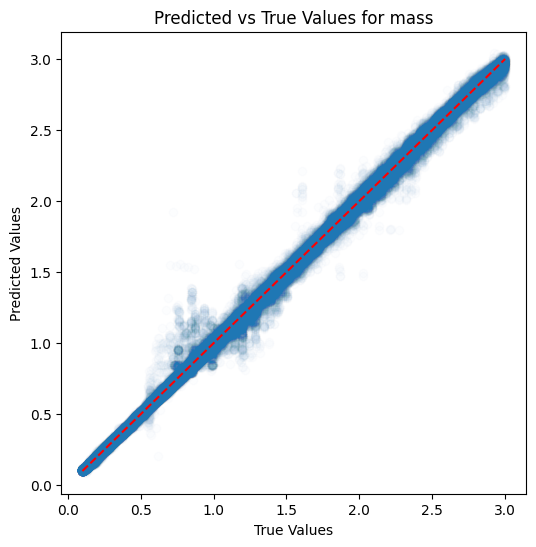

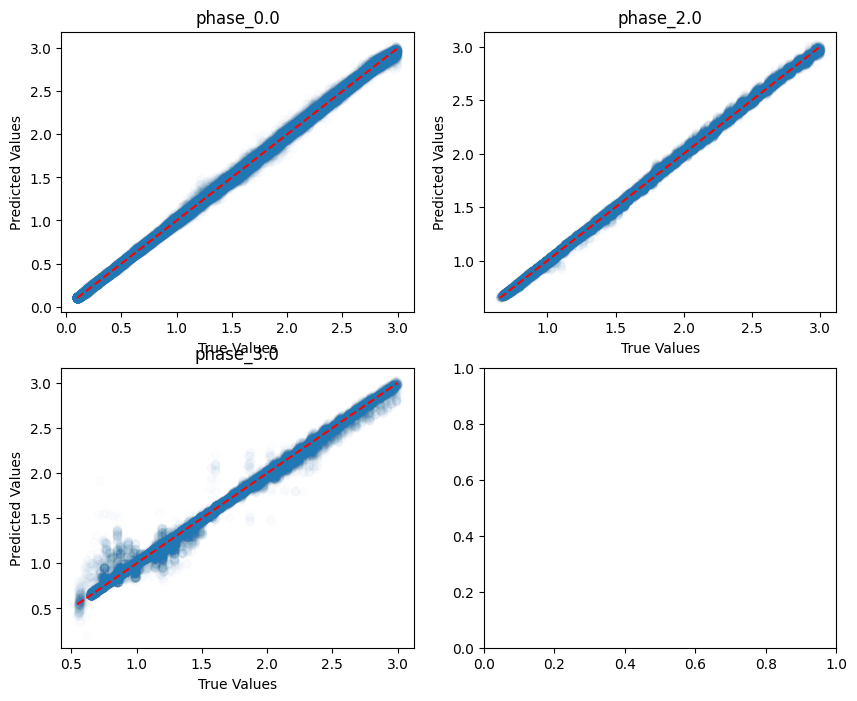

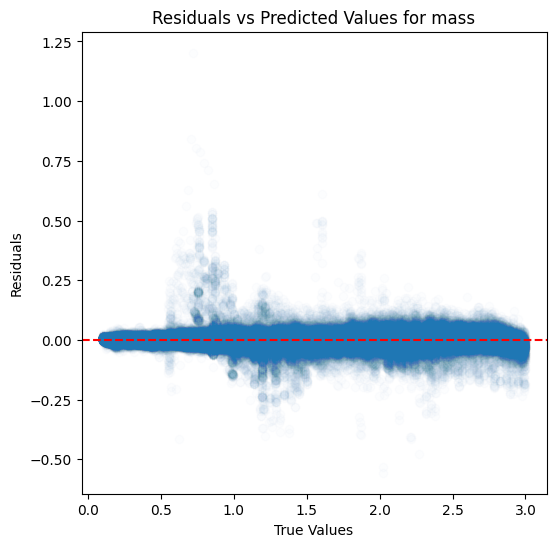

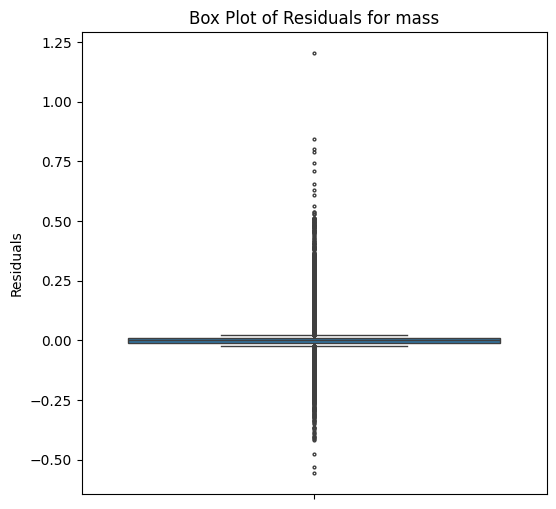

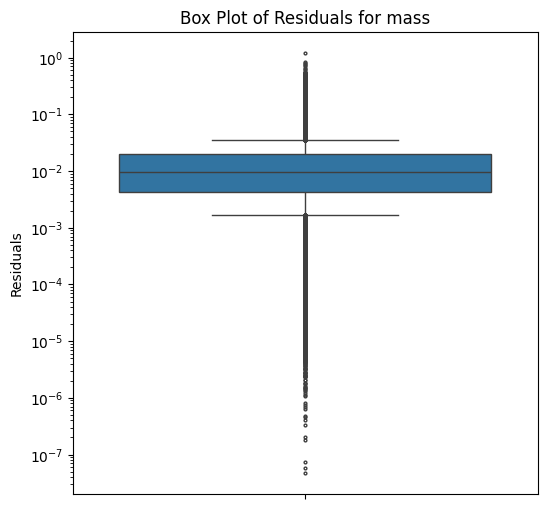

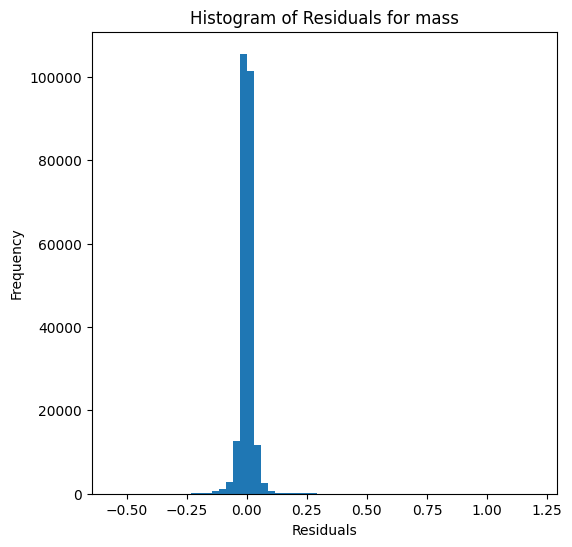

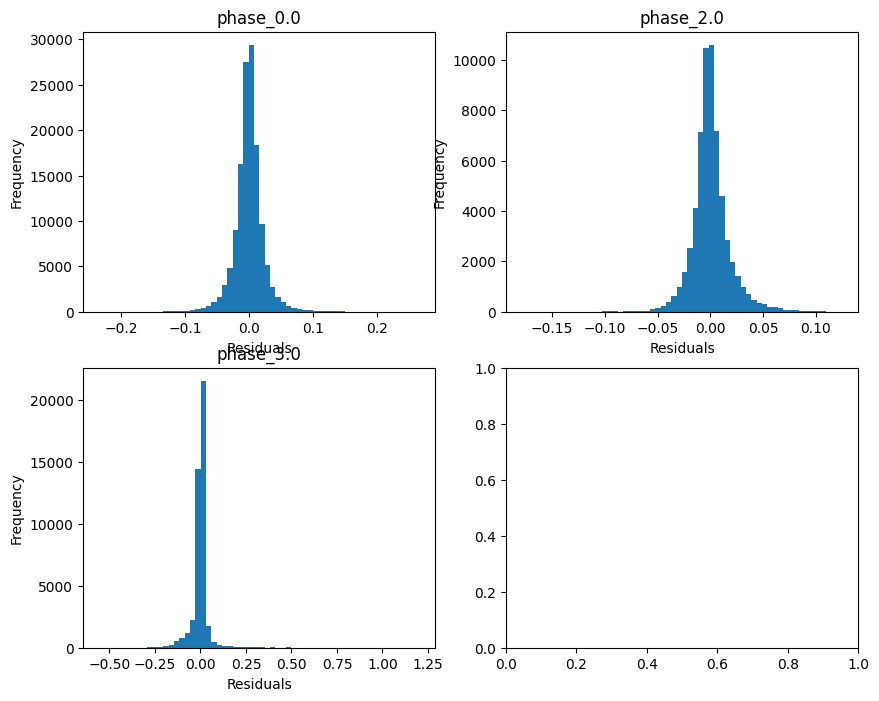

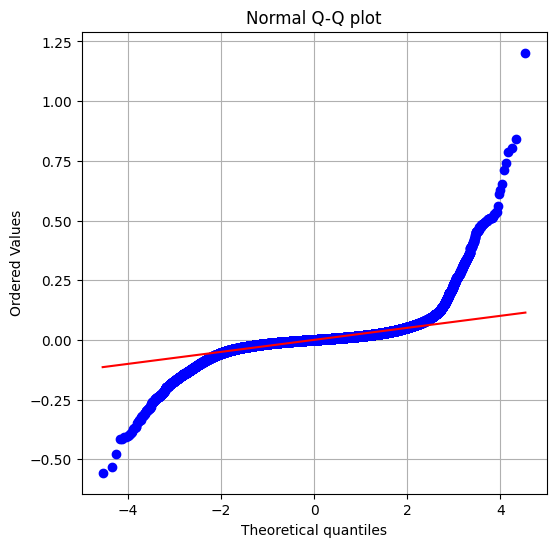

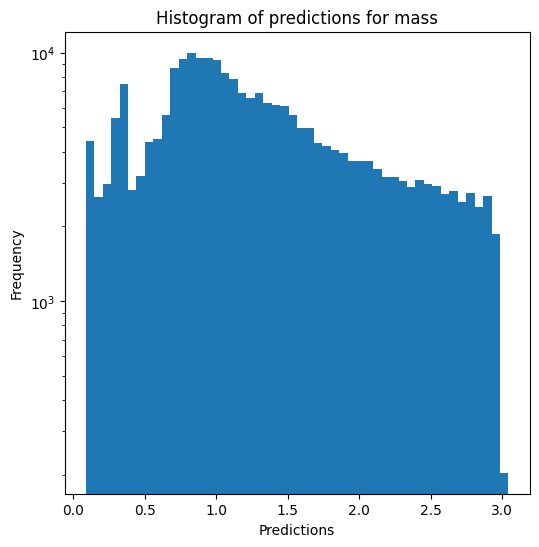

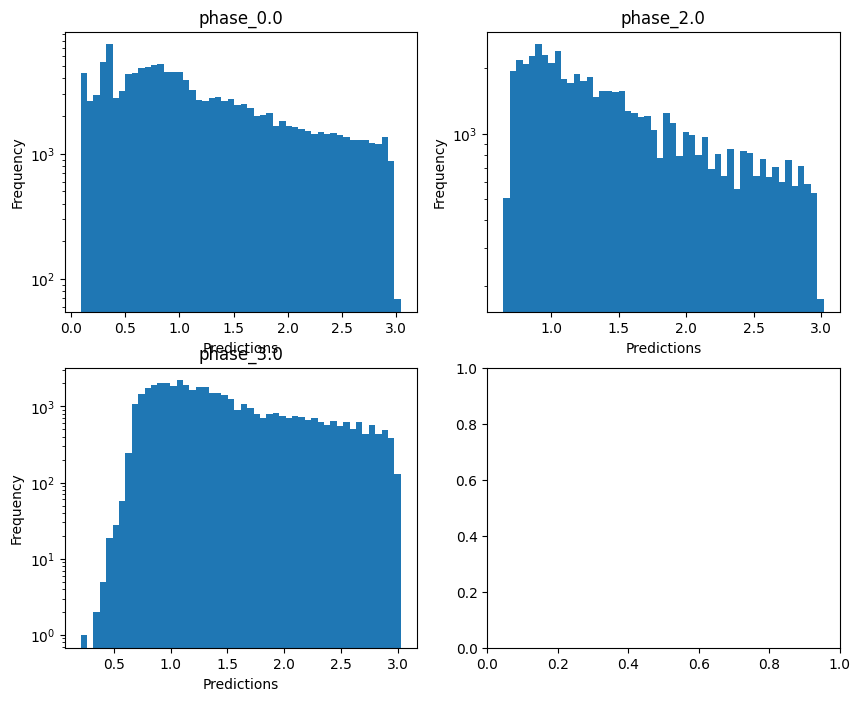

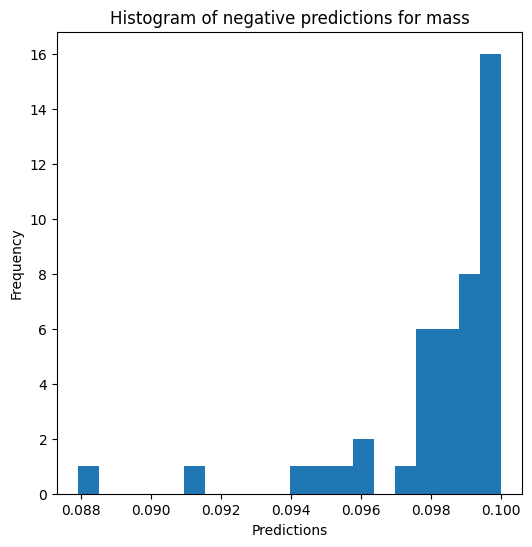


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9996075937684589
  RMSE :  0.006309289374780288
  MAE :  0.004799306778544469
  MedAE :  0.003775575297135028
  CORR :  0.9998037782605148
  MAX_ER :  0.10965551976791021
  Percentiles : 
    75th percentile :  0.0067160313309486755
    90th percentile :  0.010215698264414885
    95th percentile :  0.01288917276338954
    99th percentile :  0.018651874536485626

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9995508512748904
  RMSE :  0.009746325163688313
  MAE :  0.007459210886357077
  MedAE :  0.0059436157699729875
  CORR :  0.9997754108047239
  MAX_ER :  0.05646418370065165
  Percentiles : 
    75th percentile :  0.0103676217264842
    90th percentile :  0.015800038385364035
    95th percentile :  0.019678799912254408
    99th percentile :  0.028653489163644574

radius results fo

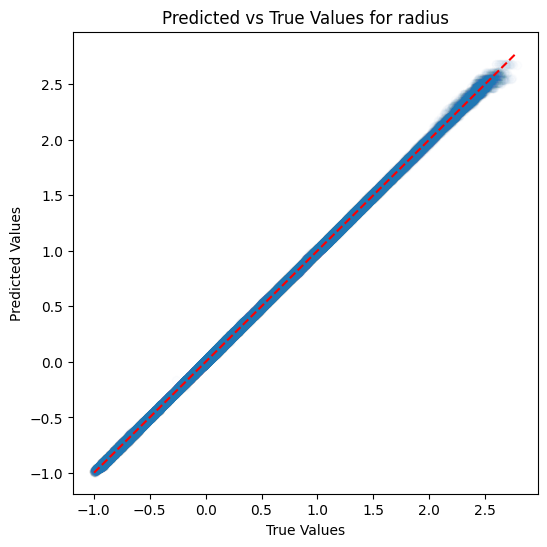

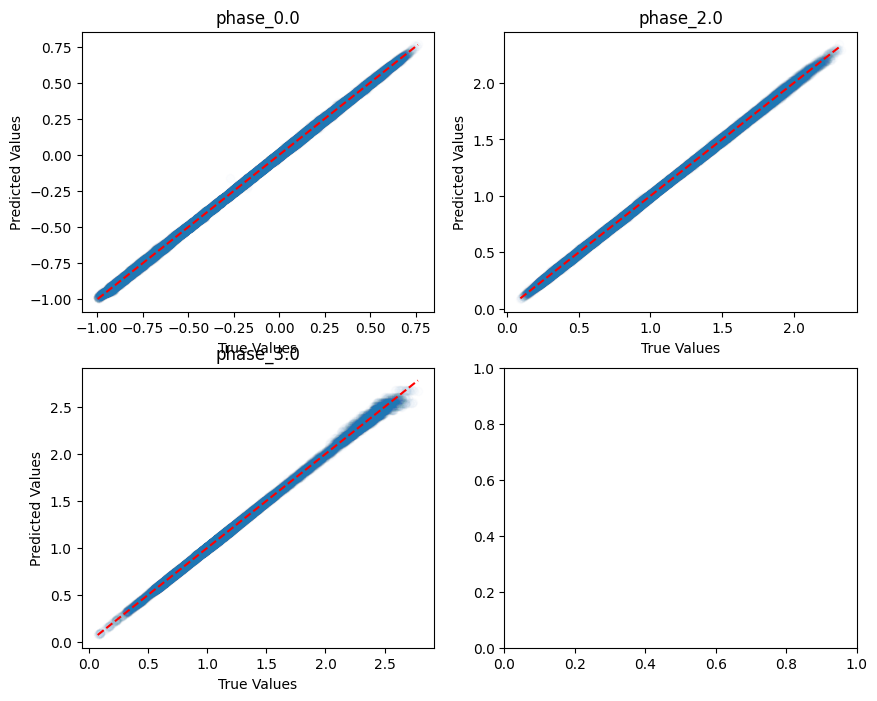

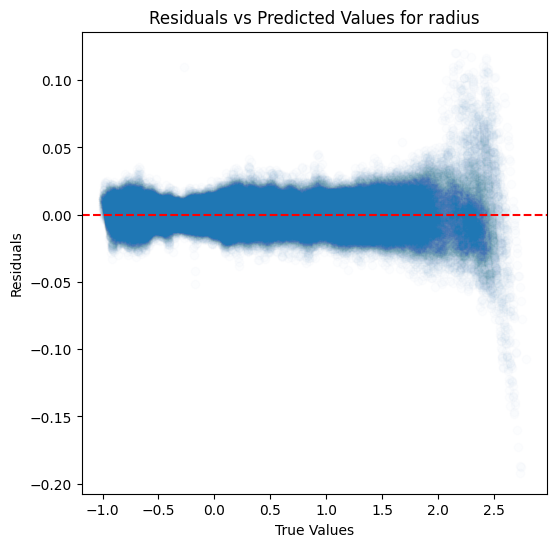

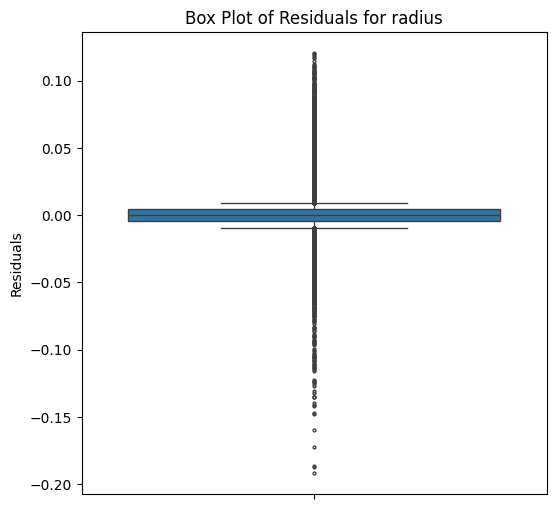

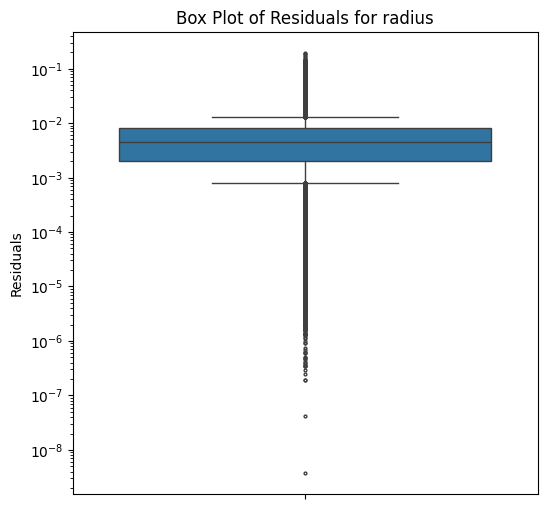

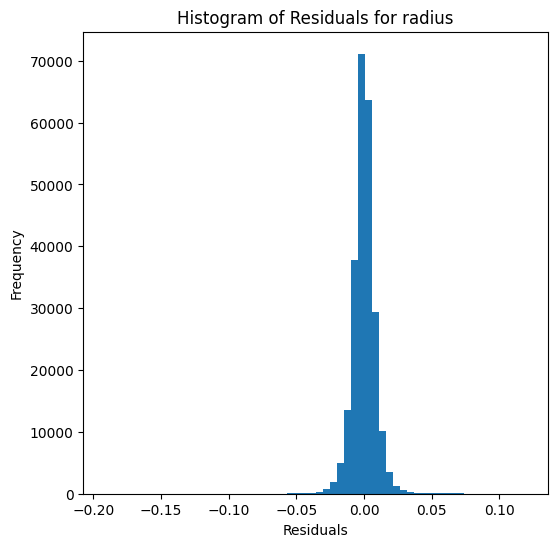

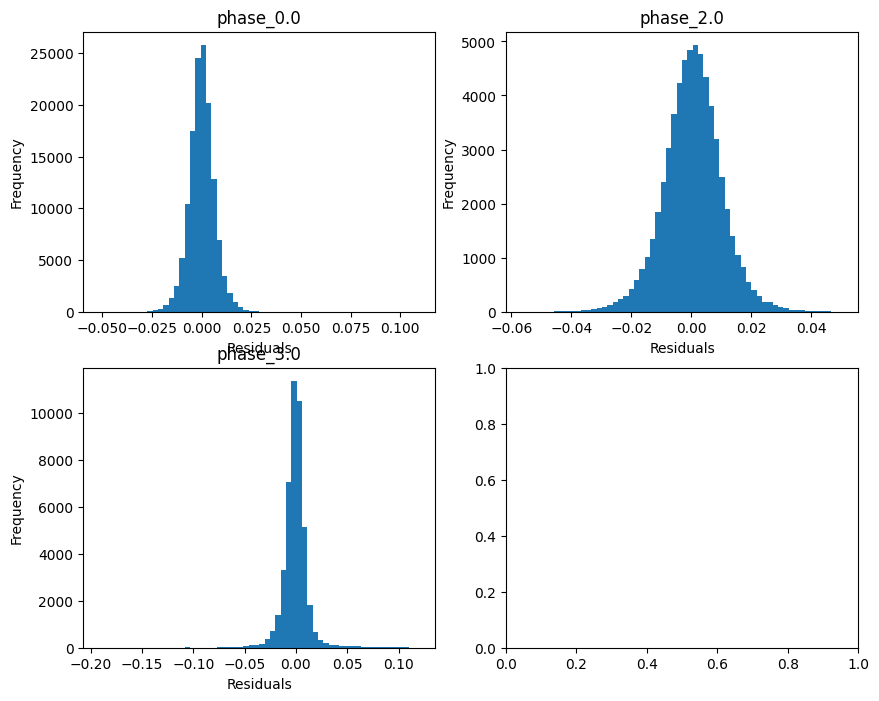

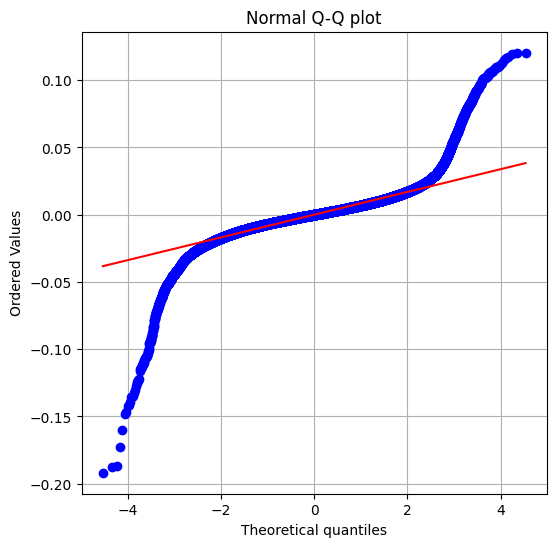

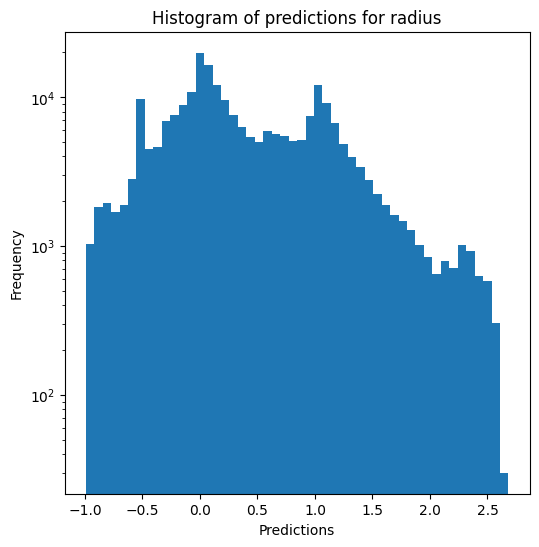

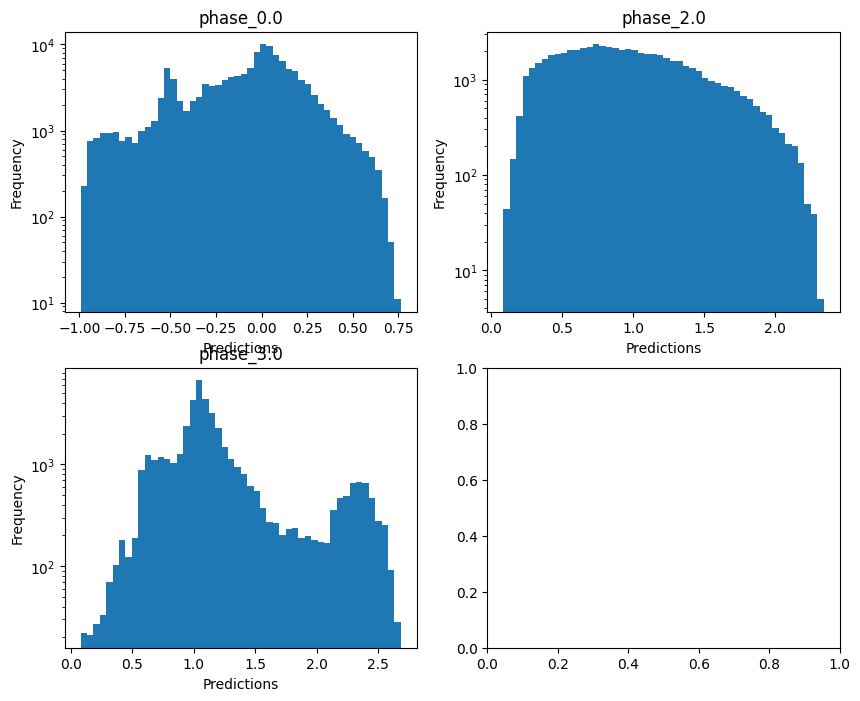

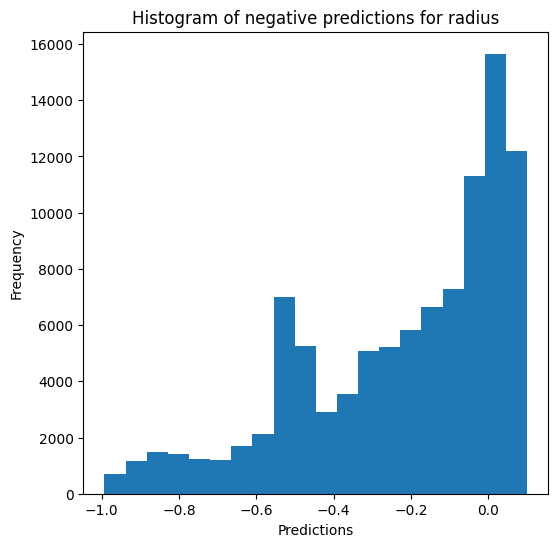

Saving results...


In [21]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, n_jobs=5)

### Multi-layer perceptron

In [22]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


mass_smaller_3 train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 2.9999868374941867
  RVE :  0.9977746446628951
  RMSE :  0.04002095137516064
  MAE :  0.027470556547414943
  MedAE :  0.018358835674302867
  CORR :  0.9989678754731477
  MAX_ER :  0.44023513695836813
  Percentiles : 
    75th percentile :  0.03715365407056309
    90th percentile :  0.06317989281402066
    95th percentile :  0.08361226087927823
    99th percentile :  0.13526520340096712

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 2.999977935638737
  RVE :  0.9935432284280881
  RMSE :  0.05773581532979746
  MAE :  0.04178708146860644
  MedAE :  0.03035615619544174
  CORR :  0.9967722337850292
  MAX_ER :  0.2954003422658218
  Percentiles : 
    75th percentile :  0.05720825498322635
    90th percentile :  0.0941300872209212
    95th percentile :  0.12216759672539756
    99th percentile :  0.

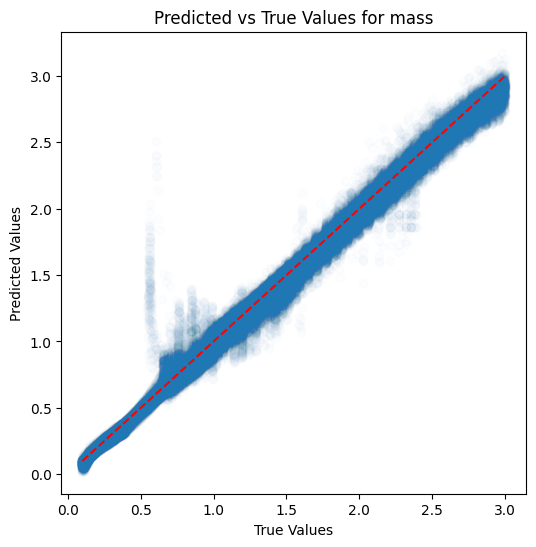

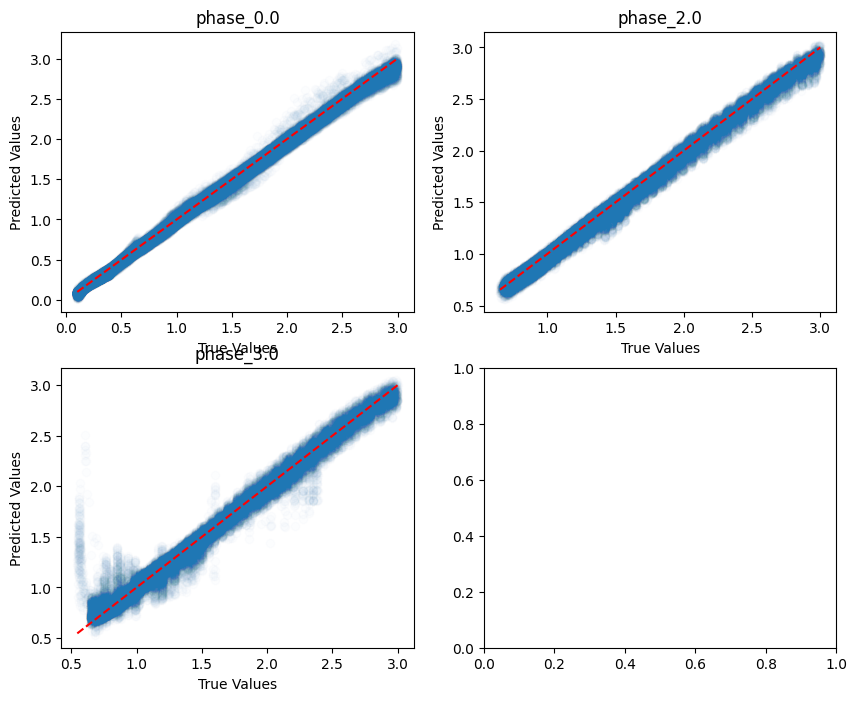

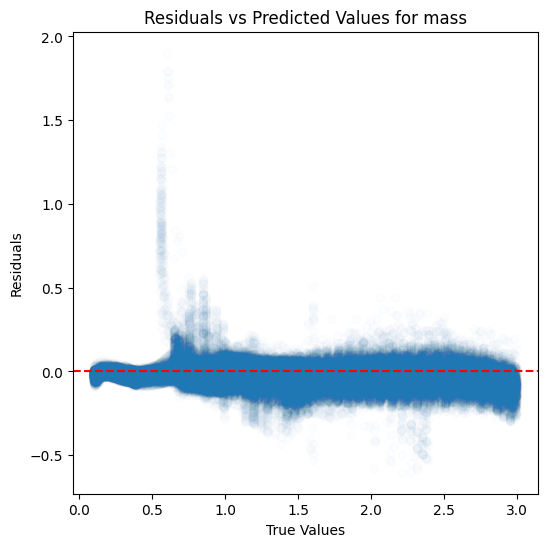

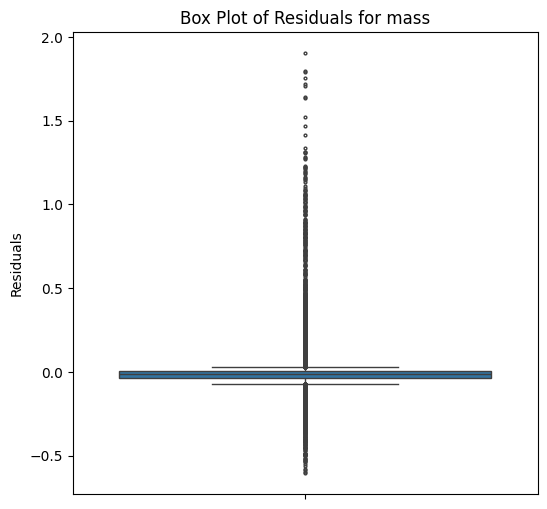

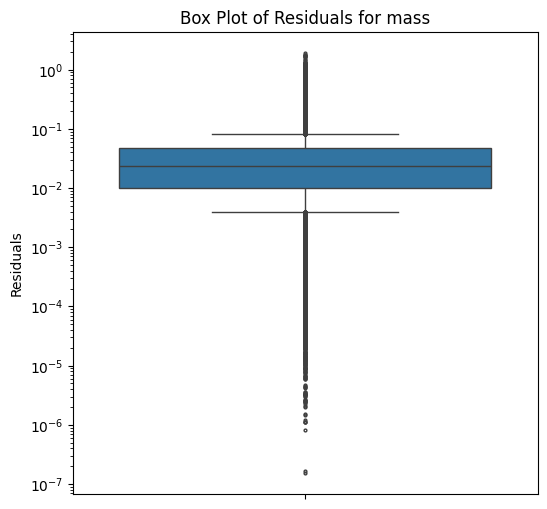

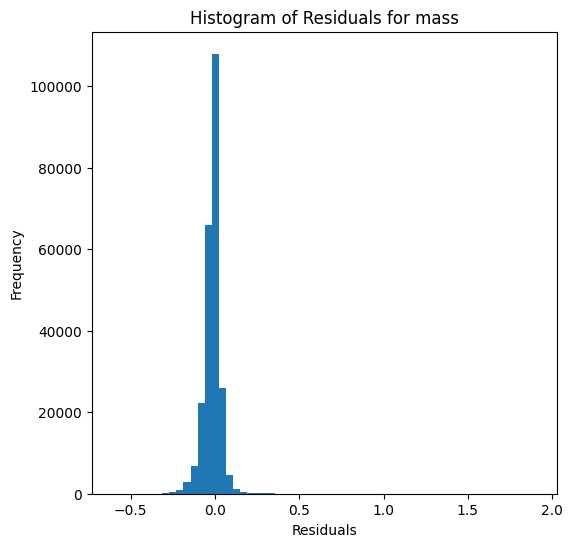

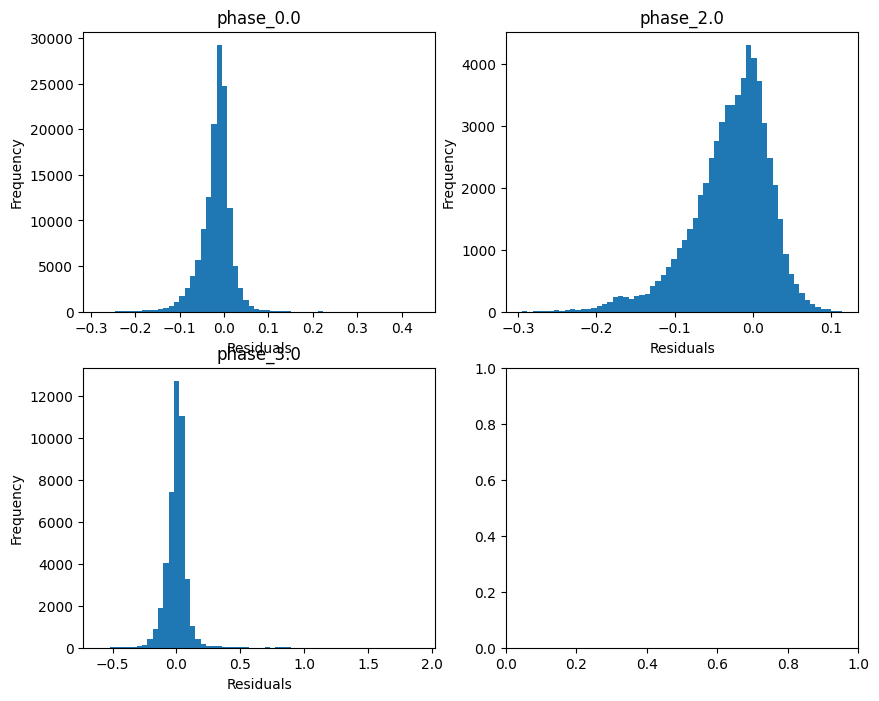

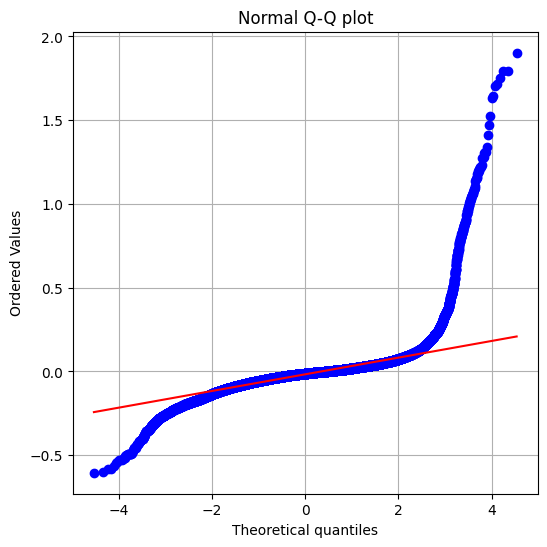

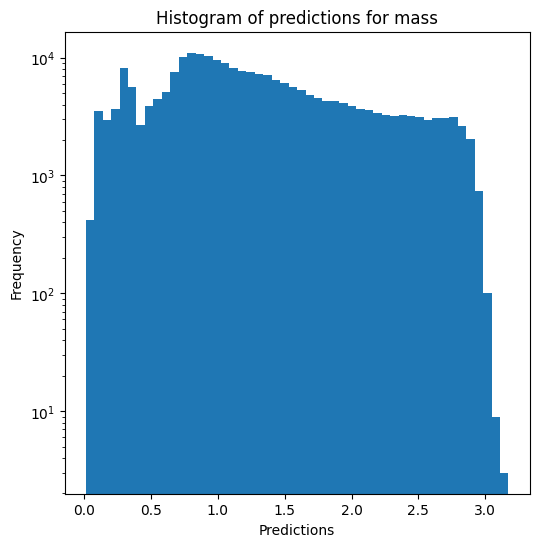

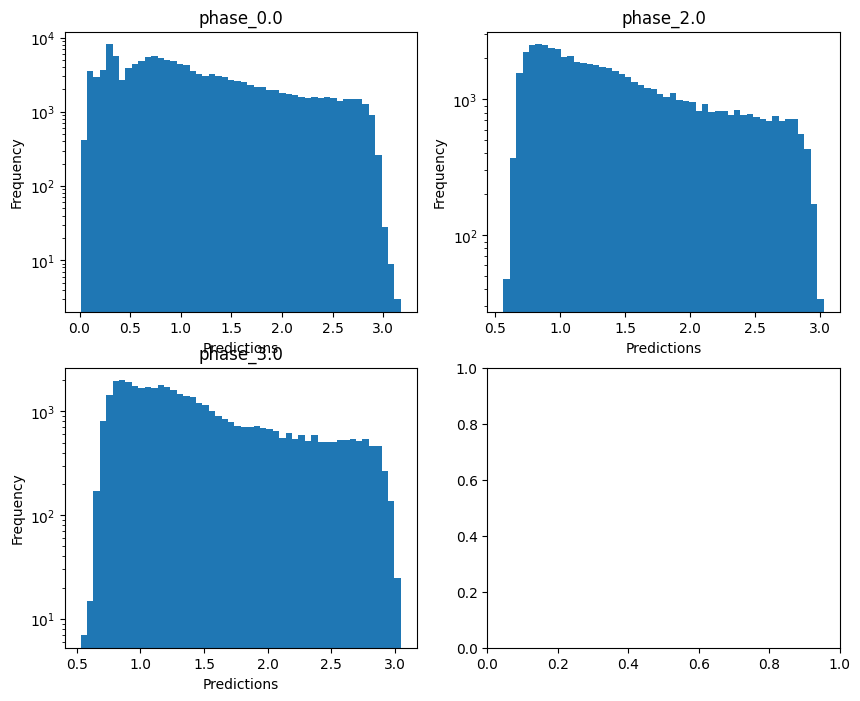

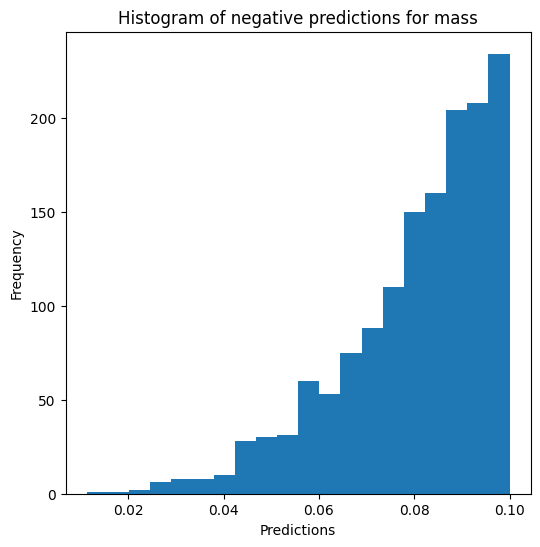


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 0.7629161677552769
  RVE :  0.9983513710056814
  RMSE :  0.01619449016001168
  MAE :  0.011837386814963746
  MedAE :  0.008215144131700552
  CORR :  0.9992197462781777
  MAX_ER :  0.0695899413541805
  Percentiles : 
    75th percentile :  0.01695370920267531
    90th percentile :  0.028028292002173872
    95th percentile :  0.034688823583052544
    99th percentile :  0.0475347113949409

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.3291459066926827
  RVE :  0.9978060724763279
  RMSE :  0.024794342966576288
  MAE :  0.017874621970560115
  MedAE :  0.011789089908206929
  CORR :  0.9989117384154471
  MAX_ER :  0.0967275312355016
  Percentiles : 
    75th percentile :  0.02430217389151046
    90th percentile :  0.04622235656624496
    95th percentile :  0.05516760530079129
    99th percentile :  0.07073282605770365

radius results for the pha

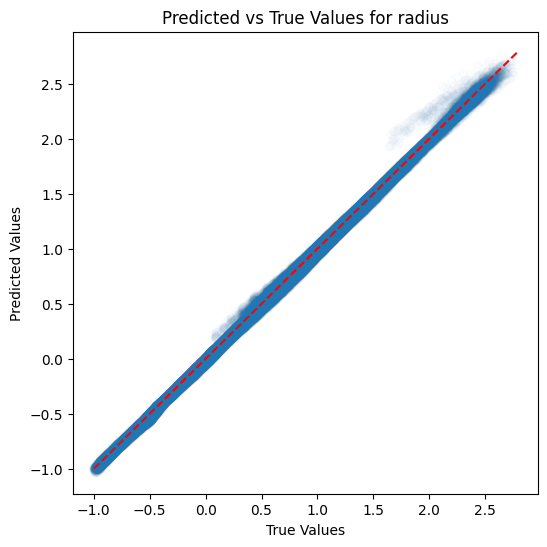

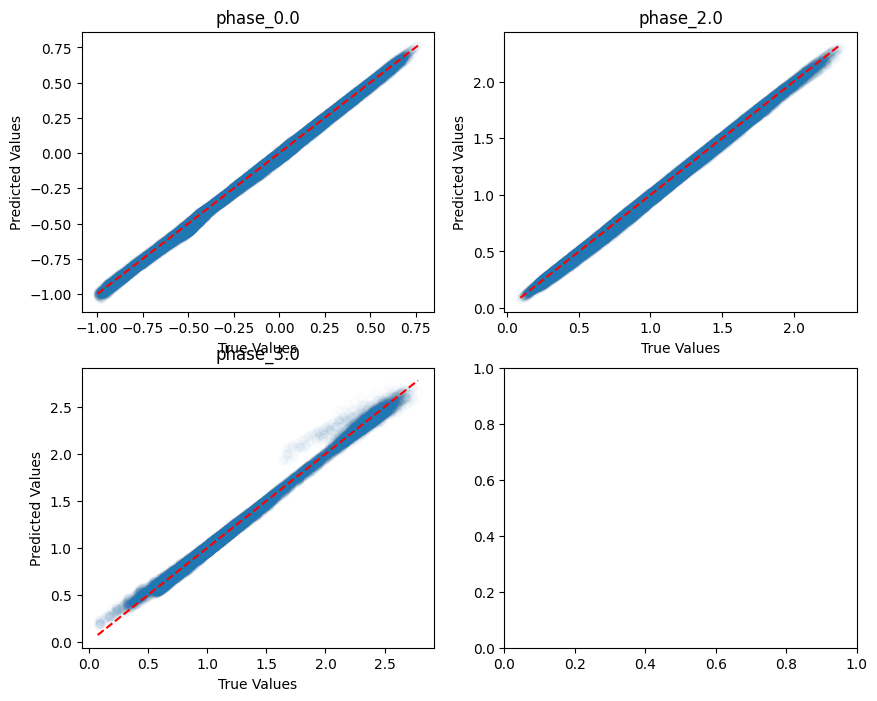

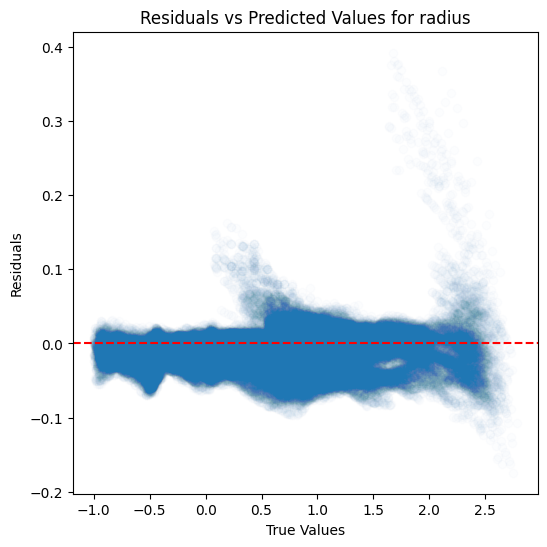

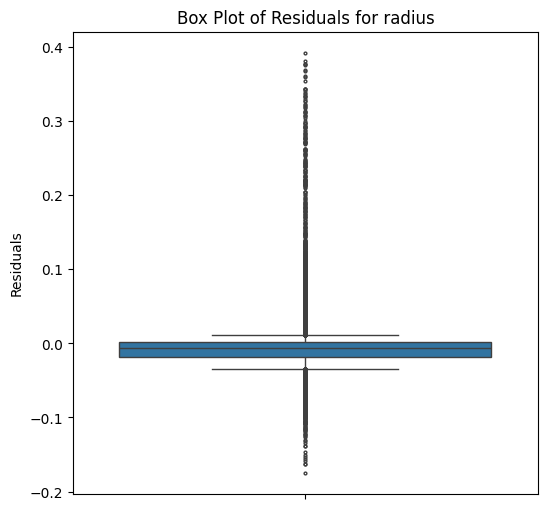

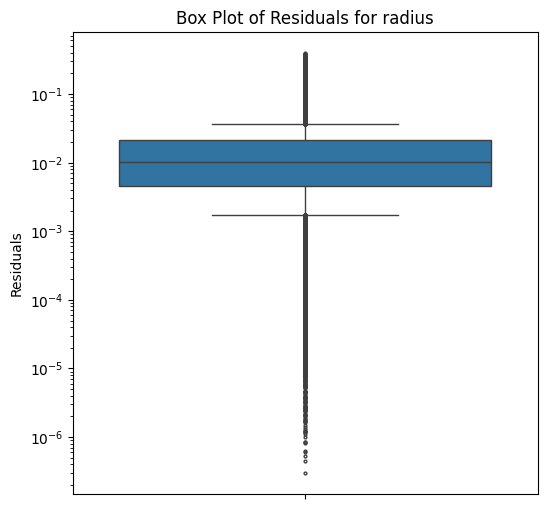

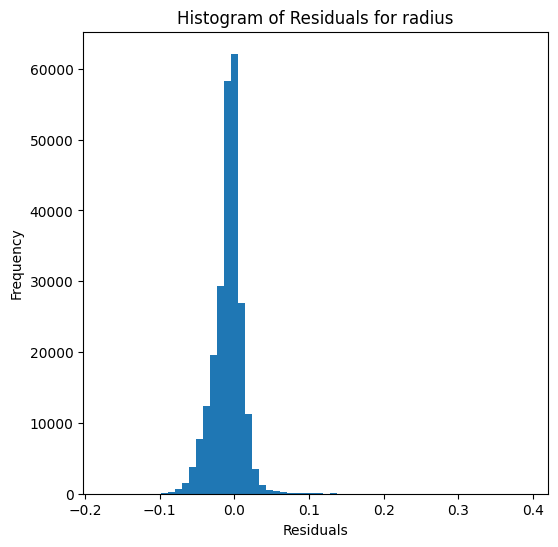

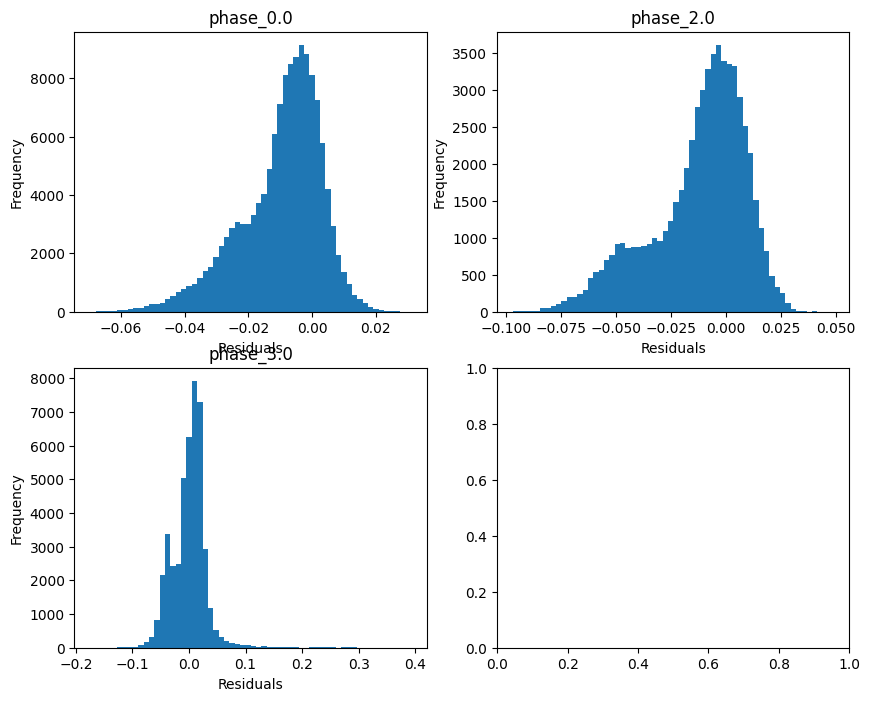

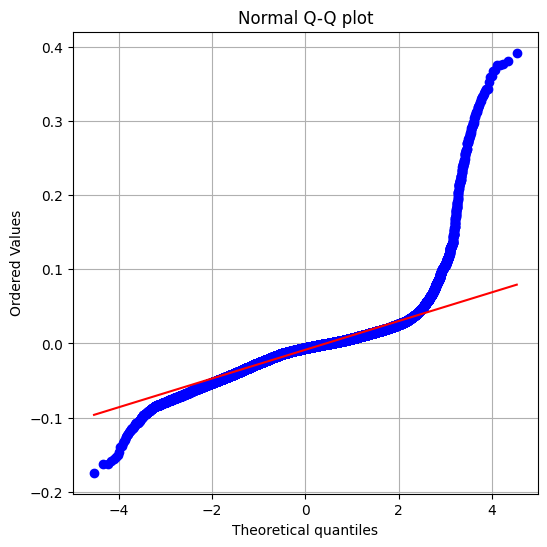

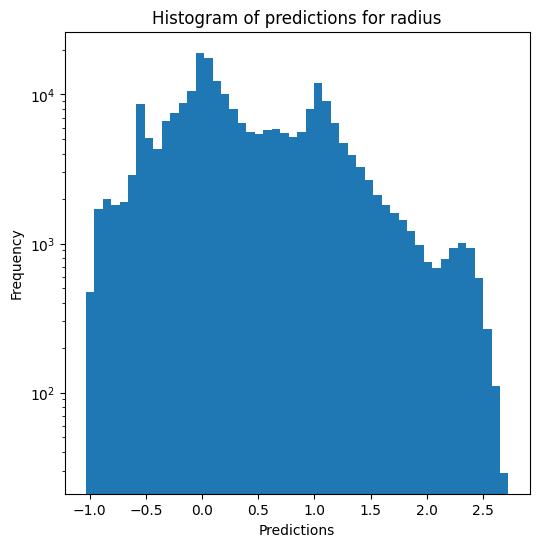

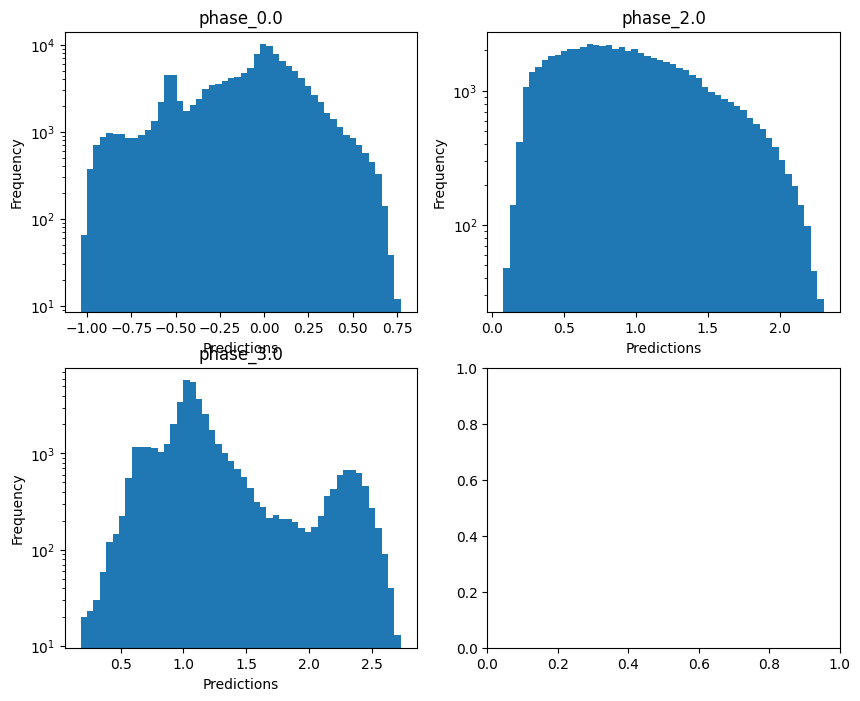

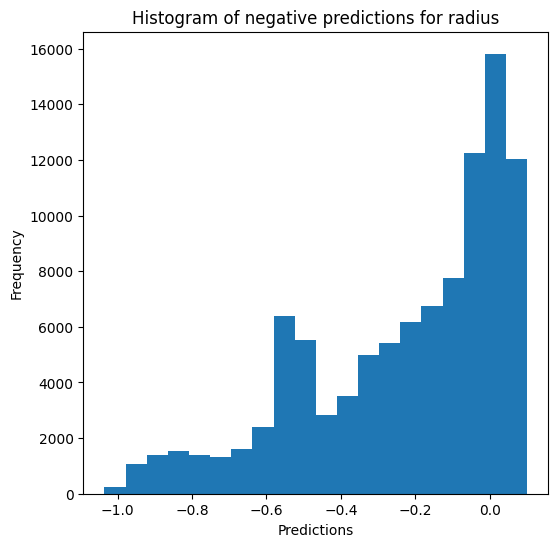

Saving results...


In [23]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, 
                                     hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400) #, override=False, use_preds=True)